# Final manuscript figure coverage

This notebook is a saved-output analysis record. It can include additional historical/intermediate plots, but it now explicitly anchors the final manuscript figures below. The canonical exported assets are in `../figures/`. Kalman panels in this notebook read saved fit/PPC outputs from `../results/`; they do not refit models or run the Kalman filter.

- **Figure 1**: General experimental procedure
- **Figure 2**: Behavioral results combined
- **Figure 3**: Cross-experiment serial dependence
- **Figure 4**: Temporal window
- **Figure 5**: Three-state Kalman filter schematic
- **Figure 6**: Parameter estimates
- **Figure 7**: Trial-level serial dependence

![Figure 1](../figures/fig1_experimental_procedure.png)

![Figure 2](../figures/fig2_behavioral_results_combined.png)

![Figure 3](../figures/fig3_cross_experiment_serial_dependence.png)

![Figure 4](../figures/fig4_temporal_window.png)

![Figure 5](../figures/fig5_three_state_kalman_filter.png)

![Figure 6](../figures/fig6_parameter_estimates.png)

![Figure 7](../figures/fig7_trial_level_serial_dependence.png)

---



# Publication Figures

This notebook generates all figures for the manuscript.

## Behavioral Results
- **Figure 1**: Experimental Design
- **Figure 2**: Central Tendency (Exp 1 & 2 combined)
- **Figure 3**: Serial Dependence (4-panel: line plots + boxplots)
- **Figure 4**: Sanity Check (n-3 to n+2 analysis)
- **Figure 5**: Cross-Experiment Comparison (SDI by Same/Switch, by Coherence, Decision Carryover)

## Computational Modeling (Figures 5-7)
- **Figure 5**: Model schematic (static manuscript asset)
- **Figure 6**: Best-model parameter estimates read from saved fit outputs
- **Figure 7**: Trial-level serial dependence read from saved PPC/trial-prediction outputs

## Supplementary Figures (S1-S4)

## Setup

In [1]:
# ============================================================
# IMPORTS - ALL REQUIRED PACKAGES
# ============================================================
import os
import sys
import json
import pickle
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import sem, ttest_rel, ttest_ind, ttest_1samp, pearsonr
from scipy.optimize import curve_fit, least_squares

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import pingouin as pg

import warnings
warnings.filterwarnings('ignore')

# Add notebook-local shared module path
import sys
from pathlib import Path
for _shared_path in (Path('shared'), Path('notebooks/shared')):
    if _shared_path.exists():
        sys.path.insert(0, str(_shared_path))

from plot_config import (
    COLORS, TRANSITION_ORDER, TRANSITION_COLORS, TRANSITION_PALETTE,
    set_nature_style, despine, add_significance_stars
)

# Figure output directory
FIG_DIR = Path('../manuscript/figures')
FIG_DIR.mkdir(exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

# Apply Nature style
set_nature_style()

# Jupyter display settings
%config InlineBackend.figure_format = 'retina'

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load data
df1 = pd.read_pickle("../data/experiment1/E1.pkl")
df1 = df1[df1["is_outlier"] == False].copy()

df2 = pd.read_pickle("../data/experiment2/E2.pkl")
df2 = df2[df2["is_outlier"] == False].copy()

# Add grouping variables
df1['SameSwitch'] = df1['TransitionType'].map({'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'})
df2['SameSwitch'] = df2['TransitionType'].map({'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'})
df2['curCoherenceLevel'] = df2['curCoherence'].map({0.3: 'Low', 0.7: 'High'})

# ============================================================
# Decision Carryover: Calculate subject-specific mean reproduction
# Mark each trial as 'Long' or 'Short' based on individual mean
# ============================================================

# Experiment 1
df1_sorted = df1.sort_values(['subID', 'trial_num']).copy()
sub_means_1 = df1_sorted.groupby('subID')['rpr'].transform('mean')
df1_sorted['ResponseType'] = np.where(df1_sorted['rpr'] > sub_means_1, 'Long', 'Short')
df1_sorted['priorResponseType'] = df1_sorted.groupby('subID')['ResponseType'].shift(1)
df1 = df1_sorted.copy()

# Experiment 2
df2_sorted = df2.sort_values(['subID', 'trial_num']).copy()
sub_means_2 = df2_sorted.groupby('subID')['rpr'].transform('mean')
df2_sorted['ResponseType'] = np.where(df2_sorted['rpr'] > sub_means_2, 'Long', 'Short')
df2_sorted['priorResponseType'] = df2_sorted.groupby('subID')['ResponseType'].shift(1)
df2 = df2_sorted.copy()

print(f"Experiment 1: {len(df1)} trials, {df1['subID'].nunique()} subjects")
print(f"Experiment 2: {len(df2)} trials, {df2['subID'].nunique()} subjects")


Experiment 1: 4659 trials, 22 subjects
Experiment 2: 4677 trials, 22 subjects


---
## Figure 1: Experimental Procedure

**Direct reference**: `manuscript/figures/image1.png`

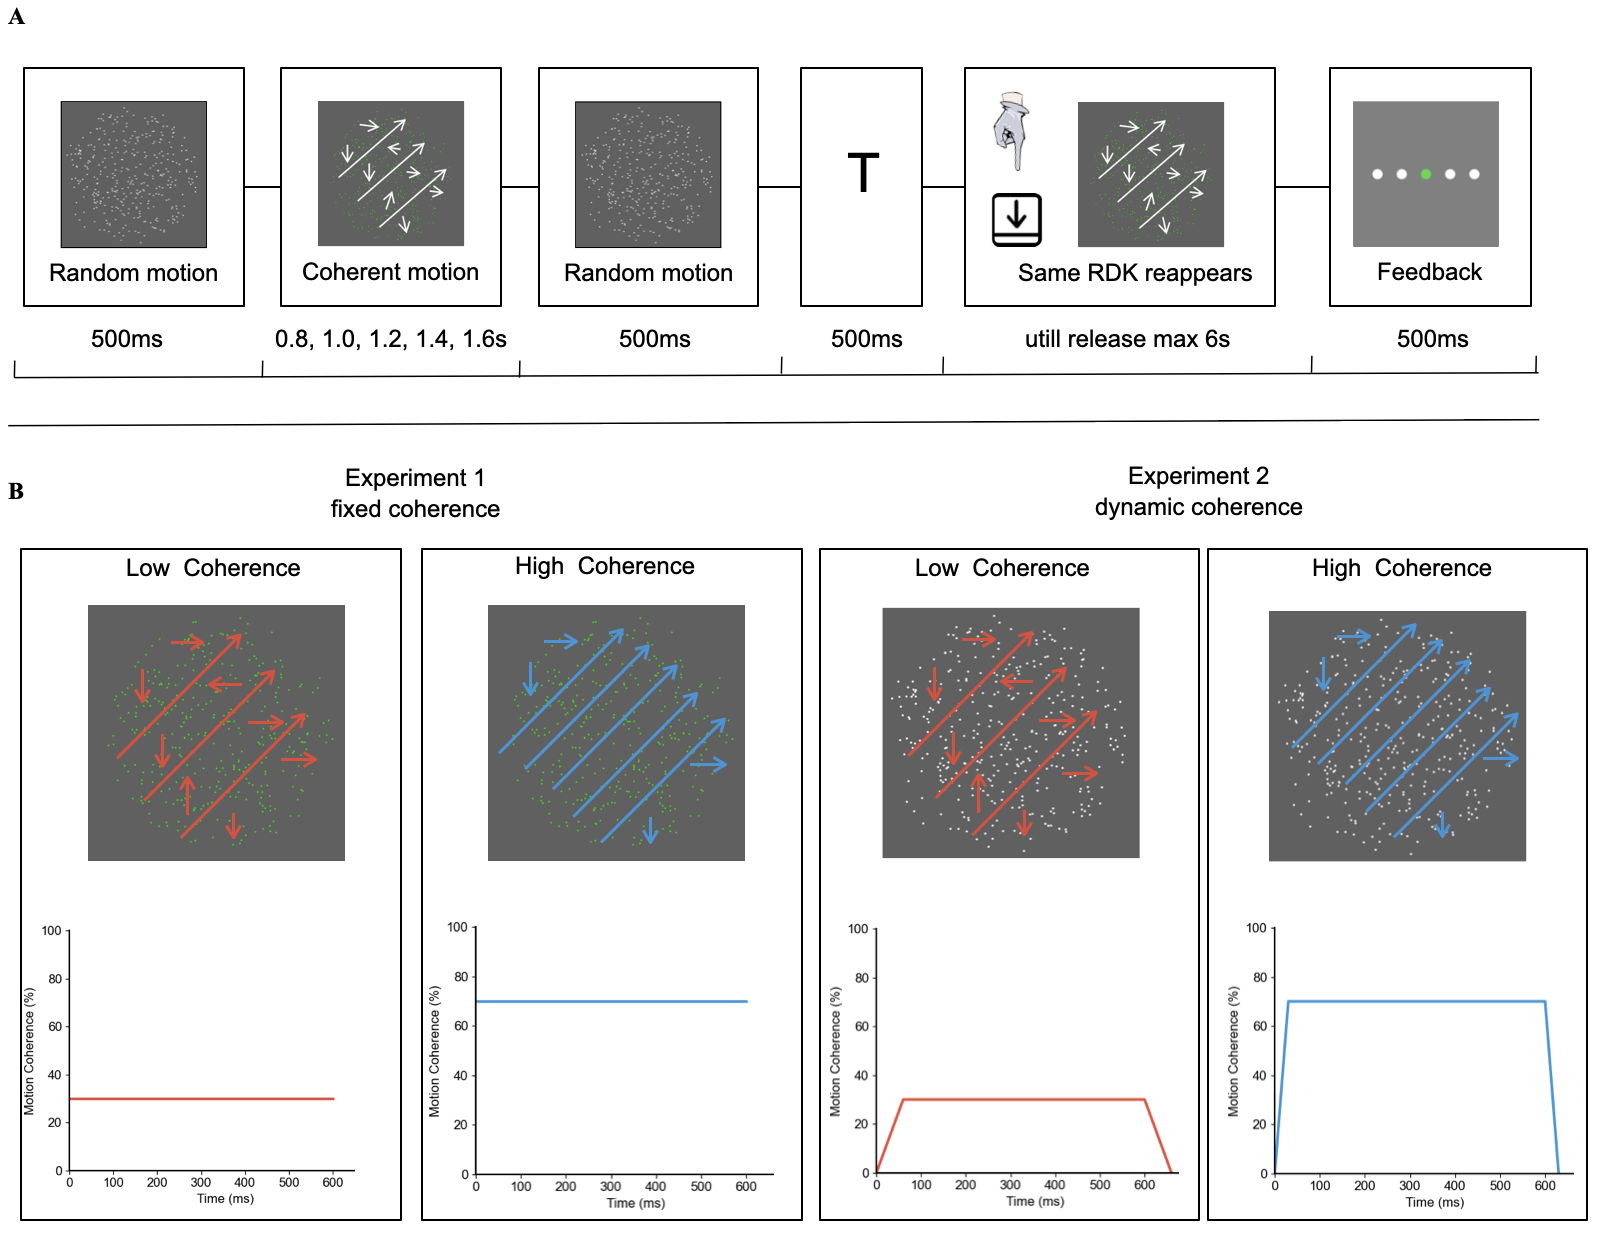

Figure 1 loaded from: ../manuscript/figures/figure1.png


In [3]:
from IPython.display import Image, display
fig1_path = FIG_DIR / 'figure1.png'
if fig1_path.exists():
    display(Image(filename=str(fig1_path), width=800))
    print(f"Figure 1 loaded from: {fig1_path}")
else:
    print(f"Figure 1 not found at: {fig1_path}")

---
## Figure 2: Central Tendency (Combined Exp 1 & 2)

- **Panel A**: Experiment 1 - Reproduction vs. current duration (4 transition types)
- **Panel B**: Experiment 2 - Reproduction vs. current duration (4 transition types)

Lines and error bars only, no bars.

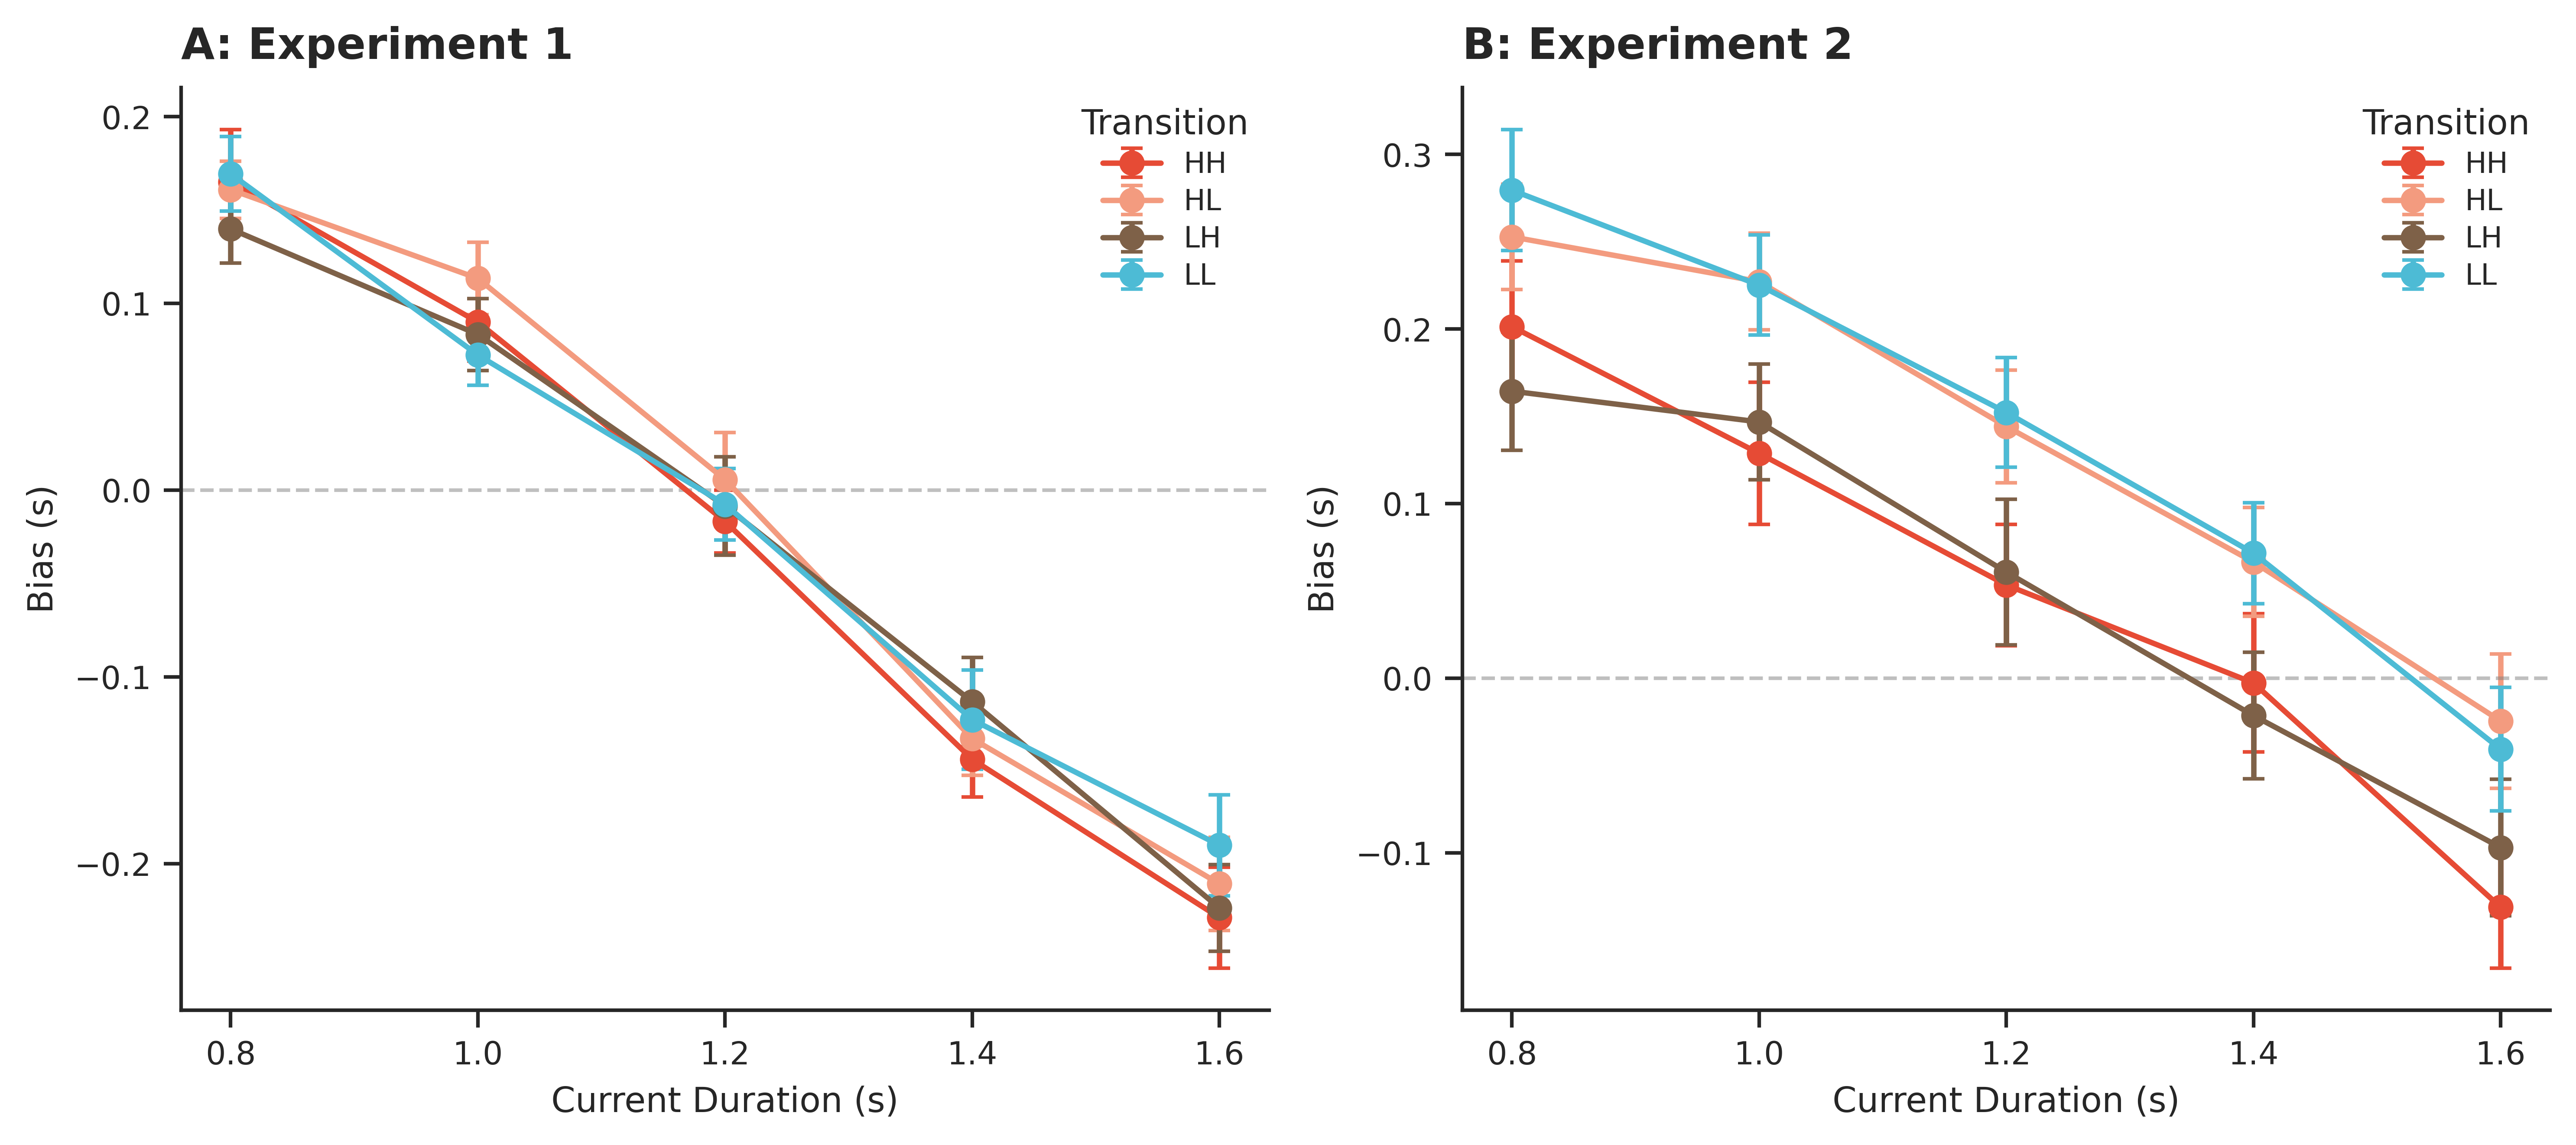

✓ Saved fig2_central_tendency


In [4]:
# Figure 2: Central Tendency - Combined Exp 1 & 2
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel A: Experiment 1
ax = axes[0]
mBiasDurPar1 = df1.groupby(['subID', 'TransitionType', 'curDur'])['curBias'].mean().reset_index()
mBiasDurAll1 = mBiasDurPar1.groupby(['TransitionType', 'curDur'])['curBias'].agg(['mean', 'sem']).reset_index()
mBiasDurAll1.columns = ['TransitionType', 'curDur', 'mBias', 'seBias']

for trans in TRANSITION_ORDER:
    sub_df = mBiasDurAll1[mBiasDurAll1['TransitionType'] == trans]
    ax.errorbar(sub_df['curDur'], sub_df['mBias'], yerr=sub_df['seBias'],
                label=trans, marker='o', linestyle='-', capsize=3,
                color=COLORS[trans], markersize=6, lw=1.5)

ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xticks(sorted(df1['curDur'].unique()))
ax.set_xlabel('Current Duration (s)')
ax.set_ylabel('Bias (s)')
ax.set_title('A: Experiment 1', loc='left', fontweight='bold', fontsize=12)
ax.legend(title='Transition', frameon=False, fontsize=8)
despine(ax)

# Panel B: Experiment 2
ax = axes[1]
mBiasDurPar2 = df2.groupby(['subID', 'TransitionType', 'curDur'])['curBias'].mean().reset_index()
mBiasDurAll2 = mBiasDurPar2.groupby(['TransitionType', 'curDur'])['curBias'].agg(['mean', 'sem']).reset_index()
mBiasDurAll2.columns = ['TransitionType', 'curDur', 'mBias', 'seBias']

for trans in TRANSITION_ORDER:
    sub_df = mBiasDurAll2[mBiasDurAll2['TransitionType'] == trans]
    ax.errorbar(sub_df['curDur'], sub_df['mBias'], yerr=sub_df['seBias'],
                label=trans, marker='o', linestyle='-', capsize=3,
                color=COLORS[trans], markersize=6, lw=1.5)

ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xticks(sorted(df2['curDur'].unique()))
ax.set_xlabel('Current Duration (s)')
ax.set_ylabel('Bias (s)')
ax.set_title('B: Experiment 2', loc='left', fontweight='bold', fontsize=12)
ax.legend(title='Transition', frameon=False, fontsize=8)
despine(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_central_tendency.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig2_central_tendency.pdf', bbox_inches='tight')
plt.show()
print('✓ Saved fig2_central_tendency')

---
## Figure 3: Serial Dependence (4 Subplots)

- **Panel A (upper left)**: Exp 1 - Bias vs. previous duration (line plot, 4 conditions)
- **Panel B (upper right)**: Exp 2 - Bias vs. previous duration (line plot, 4 conditions)
- **Panel C (lower left)**: Exp 1 - SDI boxplots grouped by Same/Switch
- **Panel D (lower right)**: Exp 2 - SDI boxplots grouped by current uncertainty

In [5]:
# Compute SDI for both experiments

# Experiment 1
sdi_list_1 = []
for (sub_id, trans_type), group in df1.groupby(['subID', 'TransitionType']):
    if len(group) >= 5:
        X = sm.add_constant(group['preDur1back'])
        y = group['curBias']
        model = sm.OLS(y, X).fit()
        slope = model.params['preDur1back']
        sdi_list_1.append({
            'subID': sub_id,
            'TransitionType': trans_type,
            'SDI': slope
        })

df_sdi_1 = pd.DataFrame(sdi_list_1)
df_sdi_1['SameSwitch'] = df_sdi_1['TransitionType'].map(
    {'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'}
)

# Experiment 2
sdi_list_2 = []
for (sub_id, trans_type), group in df2.groupby(['subID', 'TransitionType']):
    if len(group) >= 5:
        X = sm.add_constant(group['preDur1back'])
        y = group['curBias']
        model = sm.OLS(y, X).fit()
        slope = model.params['preDur1back']
        sdi_list_2.append({
            'subID': sub_id,
            'TransitionType': trans_type,
            'SDI': slope
        })

df_sdi_2 = pd.DataFrame(sdi_list_2)
df_sdi_2['curCoherenceLevel'] = df_sdi_2['TransitionType'].map(
    {'HH': 'Low', 'HL': 'High', 'LH': 'Low', 'LL': 'High'}
)

print(f"Exp 1 SDI: {len(df_sdi_1)} observations")
print(f"Exp 2 SDI: {len(df_sdi_2)} observations")

Exp 1 SDI: 88 observations
Exp 2 SDI: 88 observations


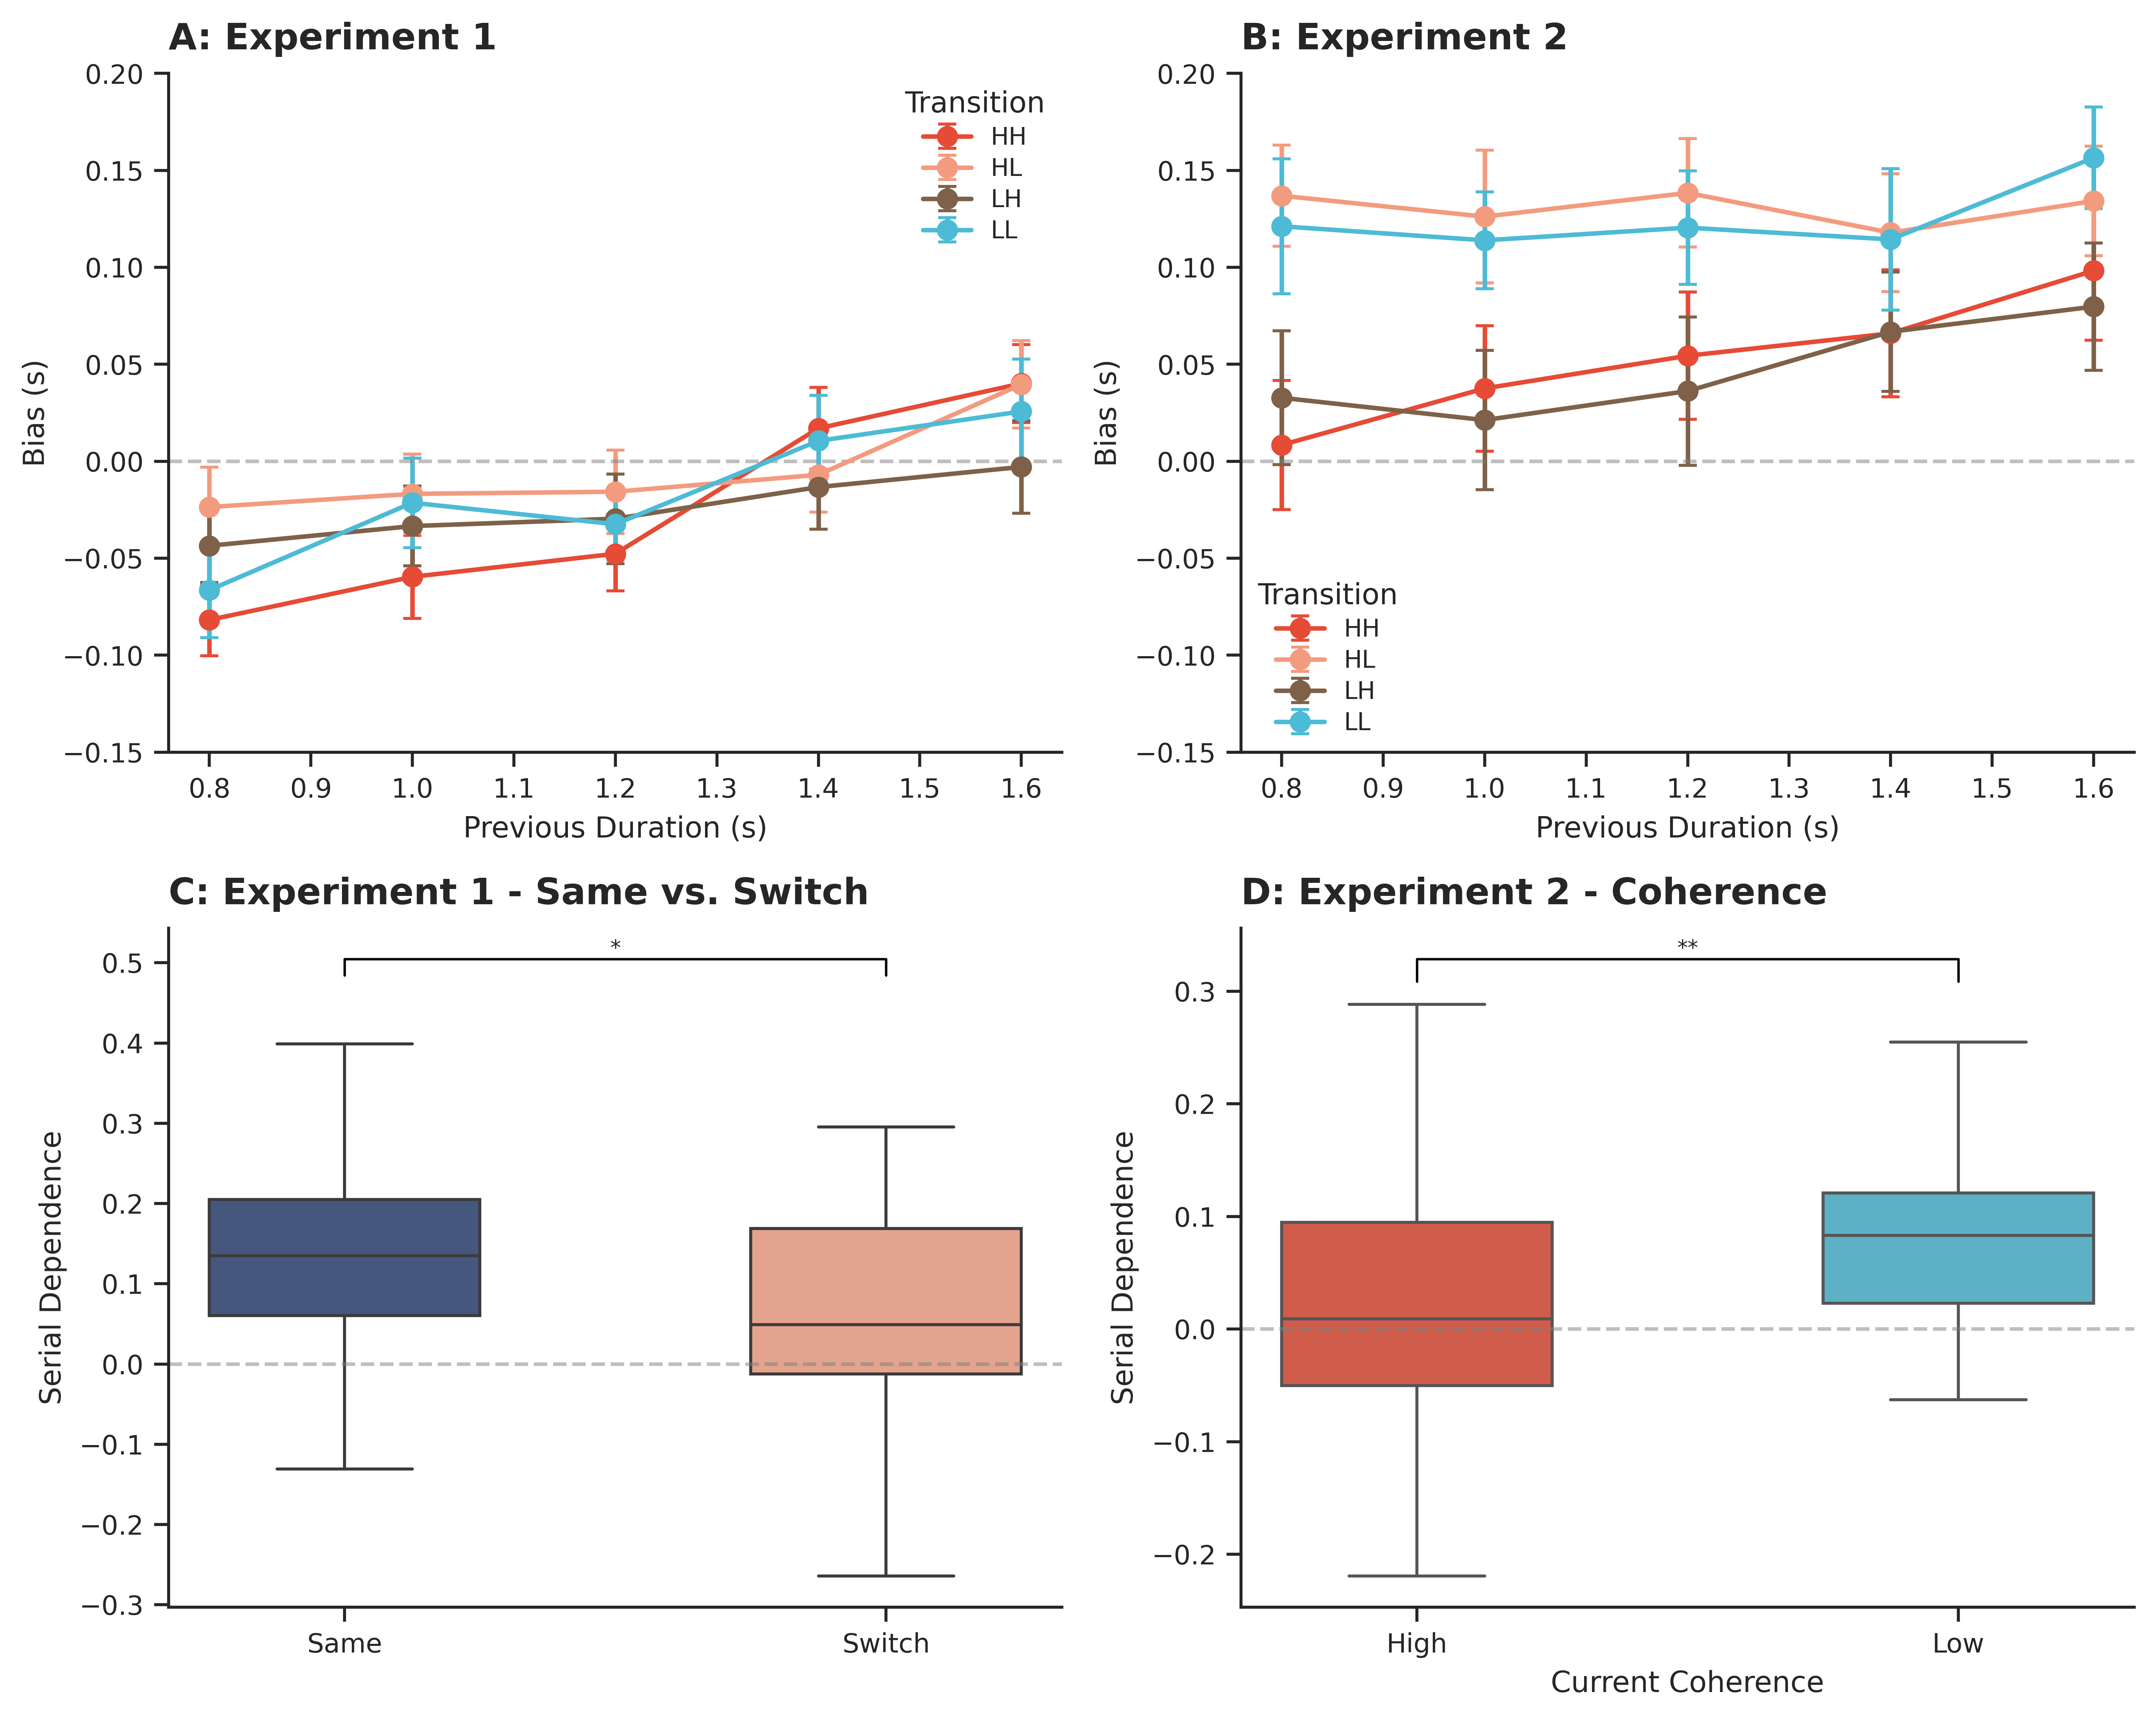

Figure 3 saved to ../manuscript/figures


In [6]:
# Figure 3: Serial Dependence (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Panel A: Exp 1 SD line plot
ax = axes[0, 0]
mBias_byPre1 = df1.groupby(['subID', 'TransitionType', 'preDur1back'])['curBias'].mean().reset_index()
mBias_byPre_all1 = mBias_byPre1.groupby(['TransitionType', 'preDur1back']).agg(
    mBias=('curBias', 'mean'),
    seBias=('curBias', 'sem')
).reset_index()

for trans in TRANSITION_ORDER:
    subdf = mBias_byPre_all1[mBias_byPre_all1['TransitionType'] == trans]
    ax.errorbar(subdf['preDur1back'], subdf['mBias'], yerr=subdf['seBias'],
                label=trans, marker='o', linestyle='-', capsize=3,
                color=COLORS[trans], markersize=6, lw=1.5)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Previous Duration (s)')
ax.set_ylabel('Bias (s)')
ax.set_title('A: Experiment 1', loc='left', fontweight='bold', fontsize=12)
ax.legend(title='Transition', frameon=False, fontsize=8)
ax.set_ylim(-0.15, 0.2)
despine(ax)

# Panel B: Exp 2 SD line plot
ax = axes[0, 1]
mBias_byPre2 = df2.groupby(['subID', 'TransitionType', 'preDur1back'])['curBias'].mean().reset_index()
mBias_byPre_all2 = mBias_byPre2.groupby(['TransitionType', 'preDur1back']).agg(
    mBias=('curBias', 'mean'),
    seBias=('curBias', 'sem')
).reset_index()

for trans in TRANSITION_ORDER:
    subdf = mBias_byPre_all2[mBias_byPre_all2['TransitionType'] == trans]
    ax.errorbar(subdf['preDur1back'], subdf['mBias'], yerr=subdf['seBias'],
                label=trans, marker='o', linestyle='-', capsize=3,
                color=COLORS[trans], markersize=6, lw=1.5)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Previous Duration (s)')
ax.set_ylabel('Bias (s)')
ax.set_title('B: Experiment 2', loc='left', fontweight='bold', fontsize=12)
ax.legend(title='Transition', frameon=False, fontsize=8)
ax.set_ylim(-0.15, 0.2)
despine(ax)

# Panel C: Exp 1 SDI boxplots - Same vs Switch
ax = axes[1, 0]
# Order: Same, Switch
order_ss = ['Same', 'Switch']
palette_ss = {'Same': COLORS['same'], 'Switch': COLORS['switch']}

sns.boxplot(data=df_sdi_1, x='SameSwitch', y='SDI', order=order_ss,
            palette=palette_ss, ax=ax, width=0.5, showfliers=False)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('Serial Dependence')
ax.set_title('C: Experiment 1 - Same vs. Switch', loc='left', fontweight='bold', fontsize=12)
despine(ax)

# Add significance test
same_sdi = df_sdi_1[df_sdi_1['SameSwitch'] == 'Same']['SDI']
switch_sdi = df_sdi_1[df_sdi_1['SameSwitch'] == 'Switch']['SDI']
t_stat, p_val = ttest_ind(same_sdi, switch_sdi)
y_max = df_sdi_1['SDI'].max() + 0.02
if p_val < 0.05:
    add_significance_stars(ax, 0, 1, y_max, p_val)

# Panel D: Exp 2 SDI boxplots - Current Uncertainty
ax = axes[1, 1]
order_unc = ['High', 'Low']
palette_unc = {'High': COLORS['high'], 'Low': COLORS['low']}  # High/Low coherence

sns.boxplot(data=df_sdi_2, x='curCoherenceLevel', y='SDI', order=order_unc,
            palette=palette_unc, ax=ax, width=0.5, showfliers=False)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Serial Dependence')
ax.set_title('D: Experiment 2 - Coherence', loc='left', fontweight='bold', fontsize=12)
despine(ax)

# Add significance test
high_unc_sdi = df_sdi_2[df_sdi_2['curCoherenceLevel'] == 'High']['SDI']
low_unc_sdi = df_sdi_2[df_sdi_2['curCoherenceLevel'] == 'Low']['SDI']
t_stat, p_val = ttest_ind(high_unc_sdi, low_unc_sdi)
y_max = df_sdi_2['SDI'].max() + 0.02
if p_val < 0.05:
    add_significance_stars(ax, 0, 1, y_max, p_val)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_serial_dependence.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig3_serial_dependence.pdf', bbox_inches='tight')
plt.show()
print(f"Figure 3 saved to {FIG_DIR}")

---
## Figure 4: Sanity Check (n-3 to n+2 Analysis)

- **Panel A**: Experiment 1 - grouped by Same/Switch
- **Panel B**: Experiment 2 - grouped by current uncertainty

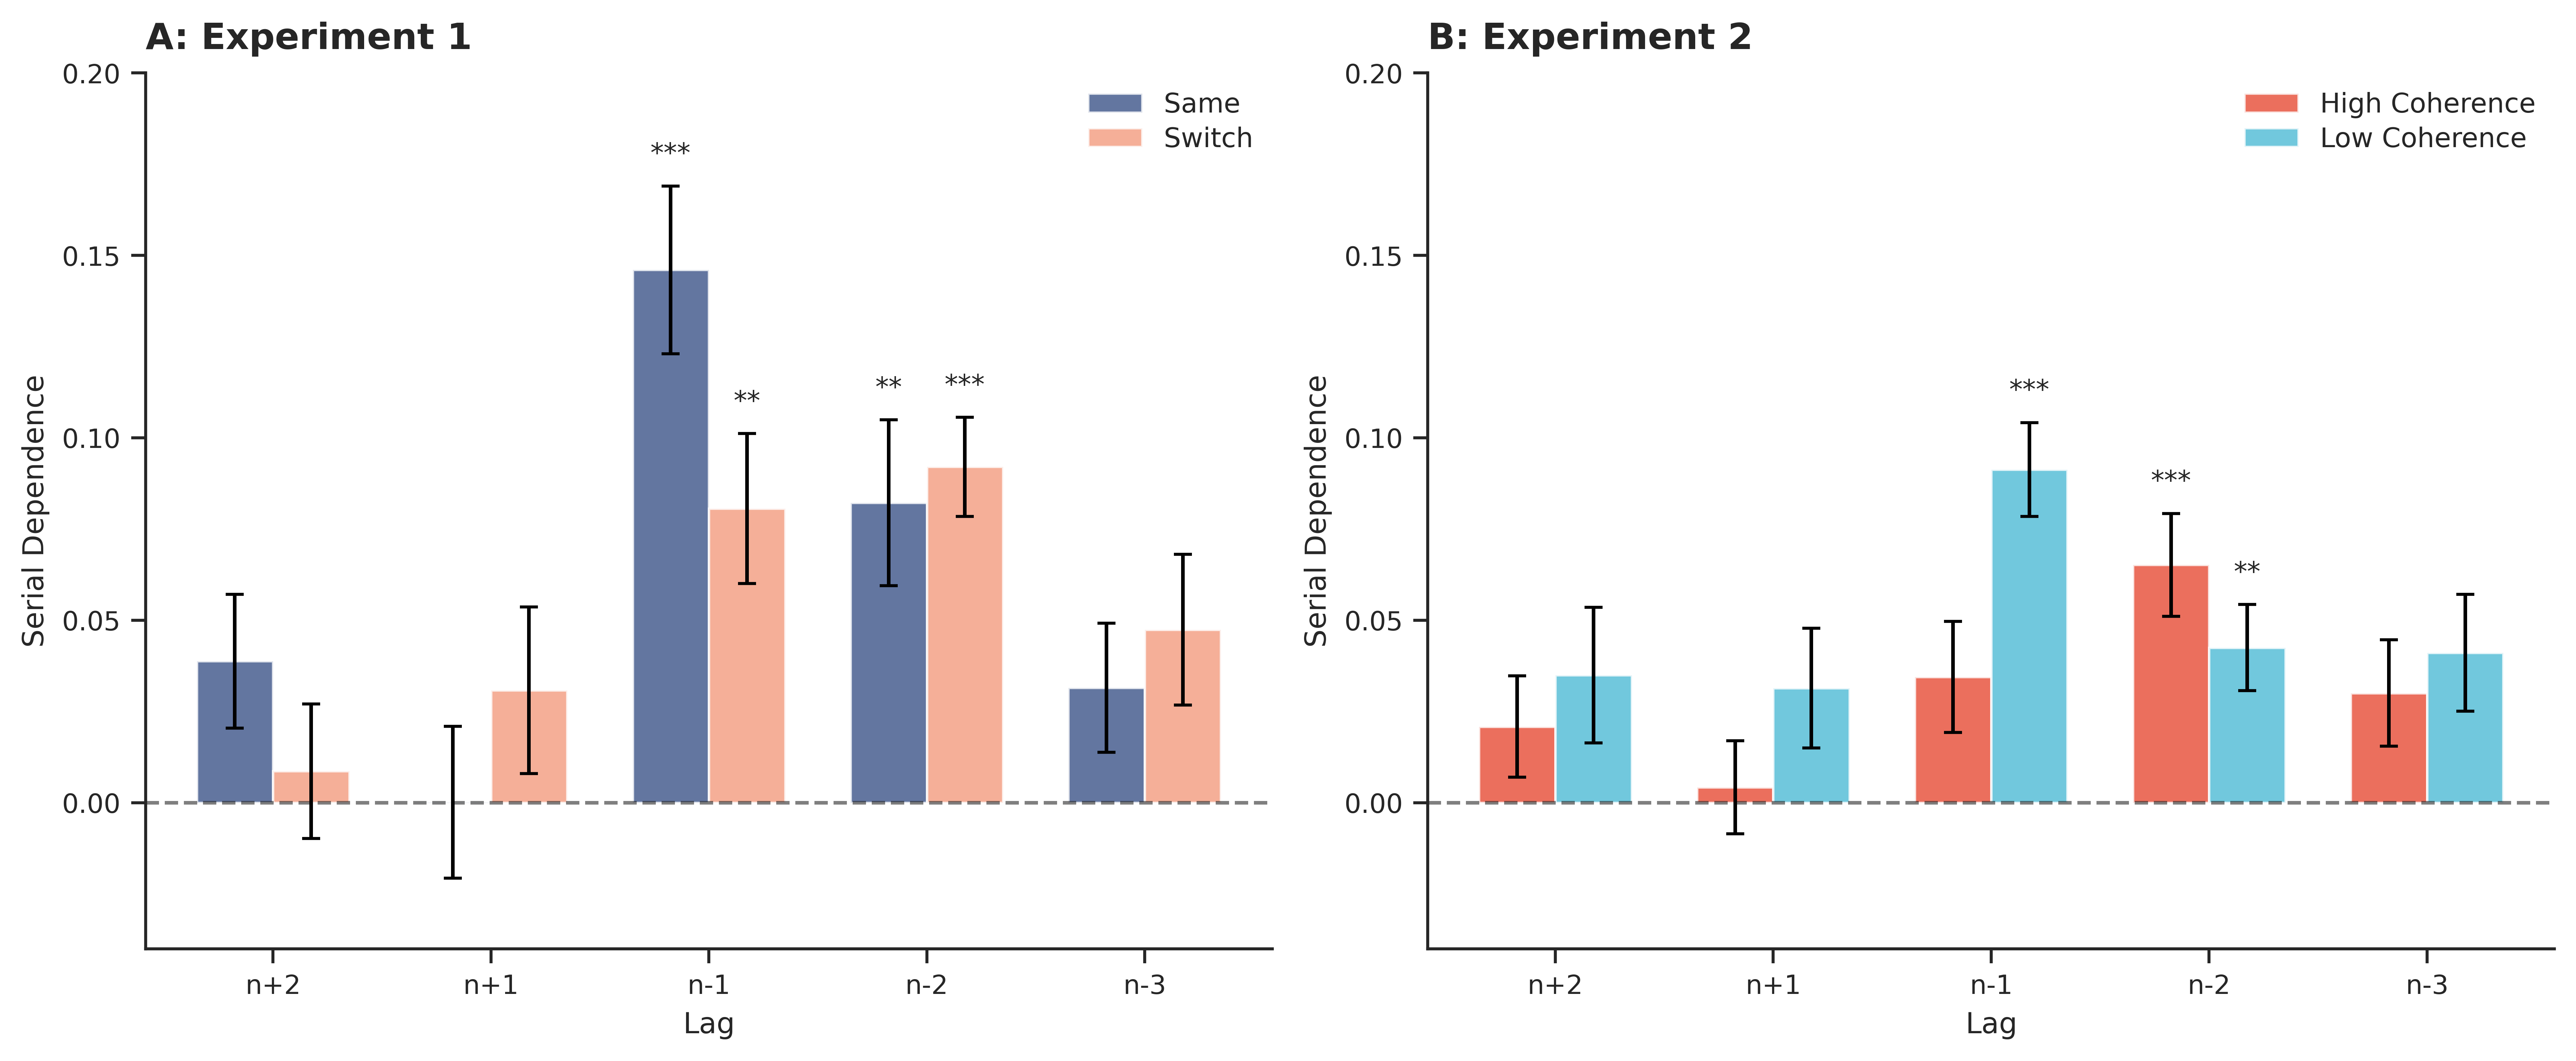

Figure 4 saved to ../manuscript/figures


In [7]:
# Figure 4: Sanity Check - n-3 to n+2 analysis

def compute_multilag_by_group(df_exp, group_col, group_values):
    """Compute SDI for n-3 to n+2 lags by group"""
    df_sorted = df_exp.sort_values(['subID', 'trial_num']).copy()
    
    # Create lag variables
    for lag in range(1, 4):
        df_sorted[f'preDur{lag}back'] = df_sorted.groupby('subID')['curDur'].shift(lag)
    
    # Future trials
    for fut in range(1, 3):
        df_sorted[f'postDur{fut}'] = df_sorted.groupby('subID')['curDur'].shift(-fut)
    
    # Variables in order: n+2, n+1, n-1, n-2, n-3
    lag_vars = ['postDur2', 'postDur1', 'preDur1back', 'preDur2back', 'preDur3back']
    lag_labels = ['n+2', 'n+1', 'n-1', 'n-2', 'n-3']
    
    results = {group: {'mean': [], 'sem': [], 'stars': []} for group in group_values}
    n_tests = len(lag_vars)
    
    for group in group_values:
        group_data = df_sorted[df_sorted[group_col] == group]
        for var in lag_vars:
            slopes = []
            for sub_id in group_data['subID'].unique():
                sub_df = group_data[group_data['subID'] == sub_id].dropna(subset=[var, 'curBias'])
                if len(sub_df) >= 5:
                    slope = np.polyfit(sub_df[var], sub_df['curBias'], 1)[0]
                    slopes.append(slope)
            
            mean_slope = np.mean(slopes) if slopes else 0
            sem_slope = sem(slopes) if len(slopes) > 1 else 0
            
            # Bonferroni-corrected significance
            if len(slopes) >= 5:
                t_stat, p_val = ttest_1samp(slopes, 0)
                p_bonf = min(p_val * n_tests, 1.0)
                star = '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else ''
            else:
                star = ''
            
            results[group]['mean'].append(mean_slope)
            results[group]['sem'].append(sem_slope)
            results[group]['stars'].append(star)
    
    return results, lag_labels

# Compute for both experiments
results_exp1, lag_labels = compute_multilag_by_group(df1, 'SameSwitch', ['Same', 'Switch'])
results_exp2, _ = compute_multilag_by_group(df2, 'curCoherenceLevel', ['High', 'Low'])

# Figure 4
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(lag_labels))
bar_width = 0.35

# Panel A: Experiment 1 - Same vs Switch
ax = axes[0]
colors_exp1 = {'Same': COLORS['same'], 'Switch': COLORS['switch']}

for i, group in enumerate(['Same', 'Switch']):
    offset = bar_width * (i - 0.5)
    bars = ax.bar(x + offset, results_exp1[group]['mean'], bar_width,
                  yerr=results_exp1[group]['sem'], capsize=3,
                  label=group, color=colors_exp1[group], alpha=0.8)
    
    # Add significance stars
    for xi, (mean_val, star) in enumerate(zip(results_exp1[group]['mean'], results_exp1[group]['stars'])):
        if star:
            y_pos = mean_val + results_exp1[group]['sem'][xi] + 0.005
            ax.text(xi + offset, y_pos, star, ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lag_labels)
ax.set_xlabel('Lag')
ax.set_ylabel('Serial Dependence')
ax.set_title('A: Experiment 1', loc='left', fontweight='bold', fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(-0.04, 0.2)
despine(ax)

# Panel B: Experiment 2 - Current Coherence
ax = axes[1]
colors_exp2 = {'High': COLORS['high'], 'Low': COLORS['low']}  # High/Low coherence
labels_exp2 = {'High': 'High Coherence', 'Low': 'Low Coherence'}

for i, group in enumerate(['High', 'Low']):
    offset = bar_width * (i - 0.5)
    bars = ax.bar(x + offset, results_exp2[group]['mean'], bar_width,
                  yerr=results_exp2[group]['sem'], capsize=3,
                  label=labels_exp2[group], color=colors_exp2[group], alpha=0.8)
    
    # Add significance stars
    for xi, (mean_val, star) in enumerate(zip(results_exp2[group]['mean'], results_exp2[group]['stars'])):
        if star:
            y_pos = mean_val + results_exp2[group]['sem'][xi] + 0.005
            ax.text(xi + offset, y_pos, star, ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lag_labels)
ax.set_xlabel('Lag')
ax.set_ylabel('Serial Dependence')
ax.set_title('B: Experiment 2', loc='left', fontweight='bold', fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(-0.04, 0.2)
despine(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_sanity_check.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig4_sanity_check.pdf', bbox_inches='tight')
plt.show()
print(f"Figure 4 saved to {FIG_DIR}")

---
## Figure 5: Cross-Experiment Comparison

- **Panel A**: Serial Dependence by Same vs. Switch (both experiments)
- **Panel B**: Serial Dependence by Current Coherence (both experiments)
- **Panel C**: Decisional Carryover by Condition

Panel A: Exp1 Same vs Switch t=4.652, p=0.0001; Exp2 t=1.734, p=0.0976


Panel B: Exp1 High vs Low t=0.643, p=0.5270; Exp2 t=2.987, p=0.0070
Panel C: Exp1 Same vs Switch t=3.879, p=0.0009; Exp2 High vs Low t=-1.924, p=0.0680


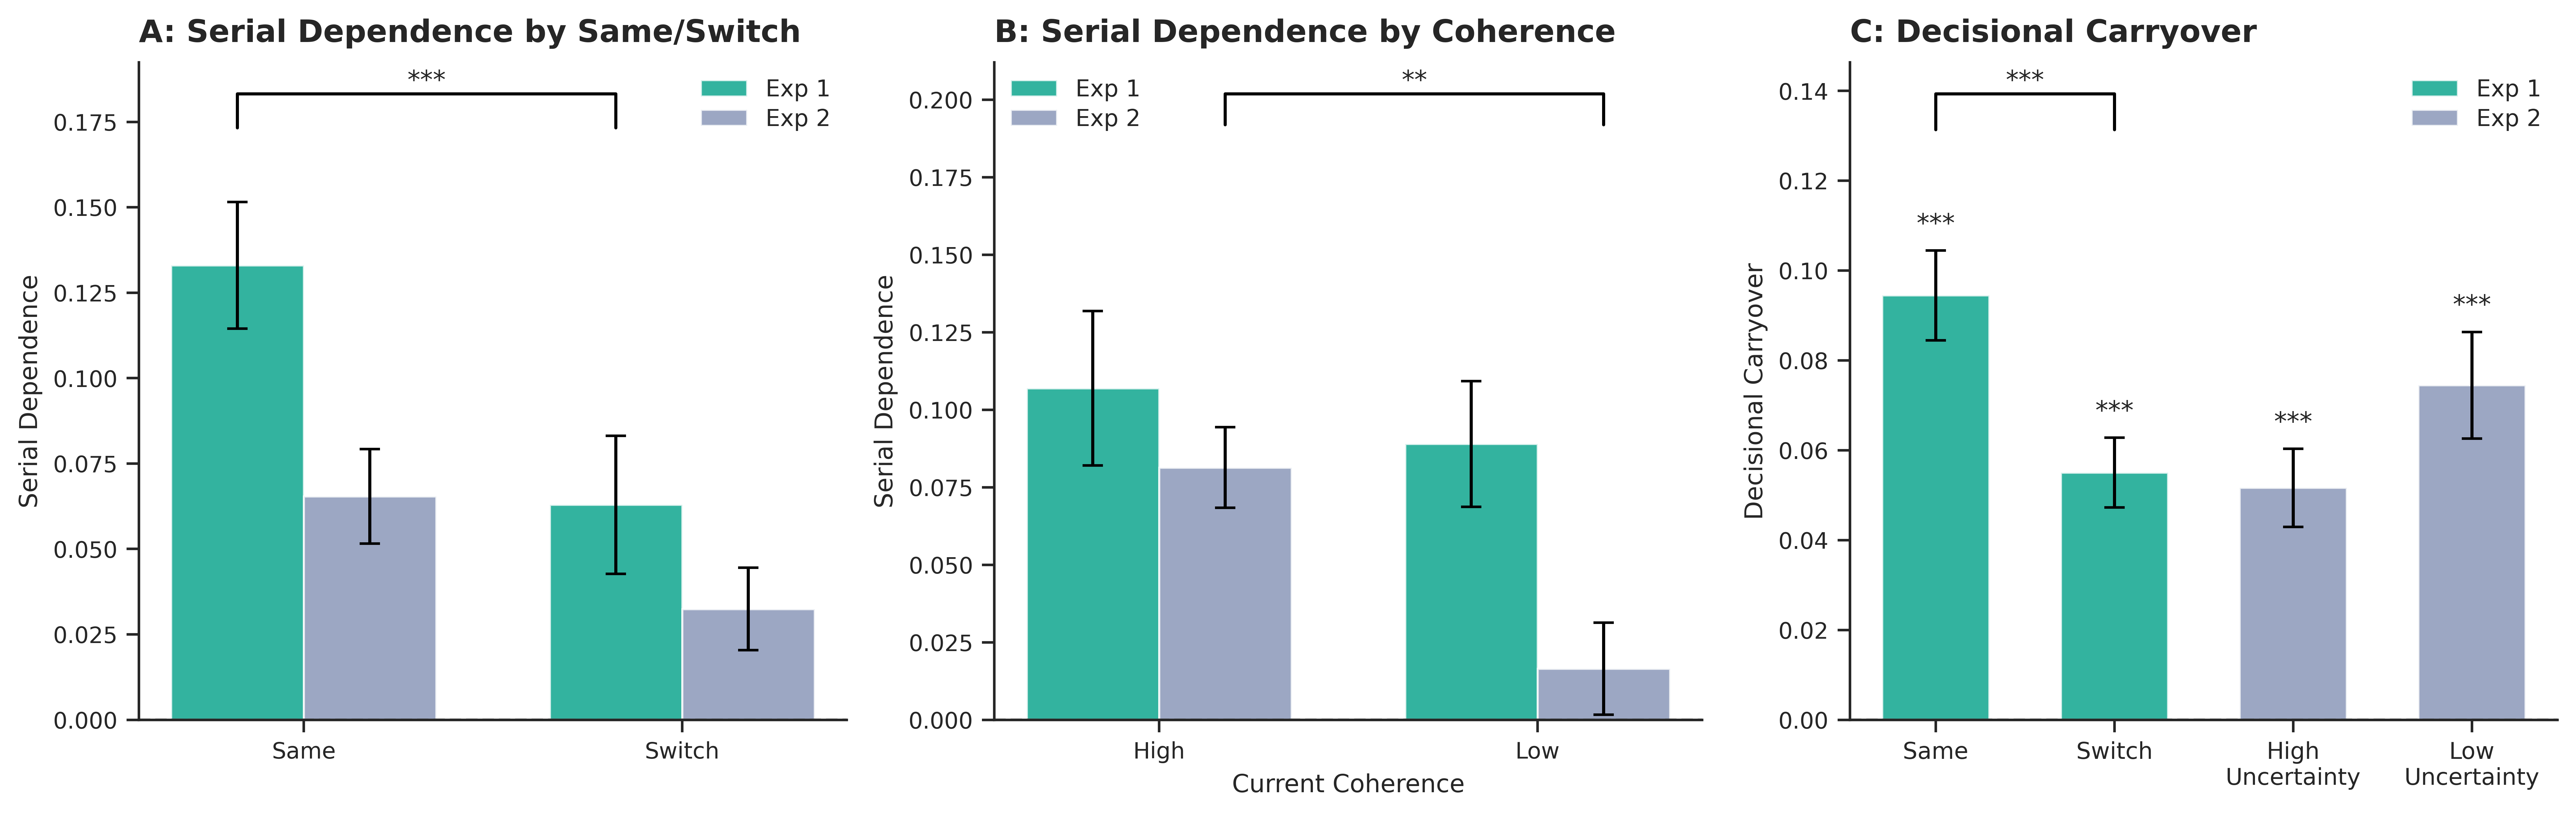


Figure 5 saved to ../manuscript/figures


In [8]:
# Figure 5: Cross-Experiment Comparison

# First, compute SDI by SameSwitch for both experiments
df_sdi_1['SameSwitch'] = df_sdi_1['TransitionType'].map(
    {'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'}
)
df_sdi_2['SameSwitch'] = df_sdi_2['TransitionType'].map(
    {'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'}
)

# Compute SDI by current coherence for both experiments
df_sdi_1['curCoh'] = df_sdi_1['TransitionType'].str[1].map({'H': 'High', 'L': 'Low'})
df_sdi_2['curCoh'] = df_sdi_2['TransitionType'].str[1].map({'H': 'High', 'L': 'Low'})

# ============================================================
# Compute Decisional Carryover
# ============================================================
def compute_dcei_by_condition(df_exp, group_col):
    """Compute DCEI grouped by condition"""
    results = []
    for sub_id in df_exp['subID'].unique():
        sub_df = df_exp[df_exp['subID'] == sub_id].dropna(subset=['priorResponseType', 'curBias'])
        if len(sub_df) < 10:
            continue
        for cond in sub_df[group_col].unique():
            cond_df = sub_df[sub_df[group_col] == cond]
            prior_long = cond_df[cond_df['priorResponseType'] == 'Long']['curBias']
            prior_short = cond_df[cond_df['priorResponseType'] == 'Short']['curBias']
            if len(prior_long) >= 5 and len(prior_short) >= 5:
                dcei = prior_long.mean() - prior_short.mean()
                results.append({'subID': sub_id, group_col: cond, 'DCEI': dcei})
    return pd.DataFrame(results)

dcei_exp1 = compute_dcei_by_condition(df1, 'SameSwitch')
dcei_exp2 = compute_dcei_by_condition(df2, 'curCoherenceLevel')

# Helper function to add significance bracket
def add_sig_bracket(ax, x1, x2, y, p_val, h=0.01, lw=1.2):
    """Add significance bracket between two x positions"""
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=10)

# Create Figure 5
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ============================================================
# Panel A: Serial Dependence by Same/Switch
# ============================================================
ax = axes[0]
sdi_ss_1 = df_sdi_1.groupby(['subID', 'SameSwitch'])['SDI'].mean().reset_index()
sdi_ss_2 = df_sdi_2.groupby(['subID', 'SameSwitch'])['SDI'].mean().reset_index()

x = np.arange(2)
width = 0.35
all_means_a, all_sems_a = [], []

for i, (exp_df, exp_name, color) in enumerate([
    (sdi_ss_1, 'Exp 1', COLORS['exp1']),
    (sdi_ss_2, 'Exp 2', COLORS['exp2'])
]):
    means, sems = [], []
    for ss in ['Same', 'Switch']:
        ss_data = exp_df[exp_df['SameSwitch'] == ss]['SDI']
        means.append(ss_data.mean())
        sems.append(sem(ss_data))
    all_means_a.append(means)
    all_sems_a.append(sems)
    ax.bar(x + width * (i - 0.5), means, width, yerr=sems, capsize=4,
           label=exp_name, color=color, alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['Same', 'Switch'])
ax.set_ylabel('Serial Dependence')
ax.set_title('A: Serial Dependence by Same/Switch', loc='left', fontweight='bold', fontsize=12)
ax.legend(frameon=False, fontsize=9)
despine(ax)

# Add significance brackets
same_1 = sdi_ss_1[sdi_ss_1['SameSwitch'] == 'Same'].set_index('subID')['SDI']
switch_1 = sdi_ss_1[sdi_ss_1['SameSwitch'] == 'Switch'].set_index('subID')['SDI']
common = same_1.index.intersection(switch_1.index)
t1, p1 = ttest_rel(same_1.loc[common], switch_1.loc[common])

same_2 = sdi_ss_2[sdi_ss_2['SameSwitch'] == 'Same'].set_index('subID')['SDI']
switch_2 = sdi_ss_2[sdi_ss_2['SameSwitch'] == 'Switch'].set_index('subID')['SDI']
common2 = same_2.index.intersection(switch_2.index)
t2, p2 = ttest_rel(same_2.loc[common2], switch_2.loc[common2])

y_max_a = max(max(all_means_a[0]) + max(all_sems_a[0]), max(all_means_a[1]) + max(all_sems_a[1])) + 0.02
if p1 < 0.05:
    add_sig_bracket(ax, -0.175, 0.825, y_max_a, p1)
if p2 < 0.05:
    add_sig_bracket(ax, 0.175, 1.175, y_max_a + 0.04, p2)

print(f"Panel A: Exp1 Same vs Switch t={t1:.3f}, p={p1:.4f}; Exp2 t={t2:.3f}, p={p2:.4f}")

# ============================================================
# Panel B: Serial Dependence by Current Coherence
# ============================================================
ax = axes[1]
all_means_b, all_sems_b = [], []

for i, (exp_df, exp_name, color) in enumerate([
    (df_sdi_1, 'Exp 1', COLORS['exp1']),
    (df_sdi_2, 'Exp 2', COLORS['exp2'])
]):
    sdi_coh = exp_df.groupby(['subID', 'curCoh'])['SDI'].mean().reset_index()
    means, sems = [], []
    for coh in ['High', 'Low']:
        coh_data = sdi_coh[sdi_coh['curCoh'] == coh]['SDI']
        means.append(coh_data.mean())
        sems.append(sem(coh_data))
    all_means_b.append(means)
    all_sems_b.append(sems)
    ax.bar(x + width * (i - 0.5), means, width, yerr=sems, capsize=4,
           label=exp_name, color=color, alpha=0.8)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Serial Dependence')
ax.set_title('B: Serial Dependence by Coherence', loc='left', fontweight='bold', fontsize=12)
ax.legend(frameon=False, fontsize=9)
despine(ax)

# Significance brackets
sdi_coh_1 = df_sdi_1.groupby(['subID', 'curCoh'])['SDI'].mean().reset_index()
high_1 = sdi_coh_1[sdi_coh_1['curCoh'] == 'High'].set_index('subID')['SDI']
low_1 = sdi_coh_1[sdi_coh_1['curCoh'] == 'Low'].set_index('subID')['SDI']
t_b1, p_b1 = ttest_rel(high_1.loc[high_1.index.intersection(low_1.index)], 
                        low_1.loc[high_1.index.intersection(low_1.index)])

sdi_coh_2 = df_sdi_2.groupby(['subID', 'curCoh'])['SDI'].mean().reset_index()
high_2 = sdi_coh_2[sdi_coh_2['curCoh'] == 'High'].set_index('subID')['SDI']
low_2 = sdi_coh_2[sdi_coh_2['curCoh'] == 'Low'].set_index('subID')['SDI']
t_b2, p_b2 = ttest_rel(high_2.loc[high_2.index.intersection(low_2.index)],
                        low_2.loc[high_2.index.intersection(low_2.index)])

y_max_b = max(max(all_means_b[0]) + max(all_sems_b[0]), max(all_means_b[1]) + max(all_sems_b[1])) + 0.02
if p_b1 < 0.05:
    add_sig_bracket(ax, -0.175, 0.825, y_max_b, p_b1)
if p_b2 < 0.05:
    add_sig_bracket(ax, 0.175, 1.175, y_max_b + 0.04, p_b2)

print(f"Panel B: Exp1 High vs Low t={t_b1:.3f}, p={p_b1:.4f}; Exp2 t={t_b2:.3f}, p={p_b2:.4f}")

# ============================================================
# Panel C: Decisional Carryover
# ============================================================
ax = axes[2]

dcei_stats_1 = {cond: {'mean': dcei_exp1[dcei_exp1['SameSwitch'] == cond]['DCEI'].mean(),
                        'sem': sem(dcei_exp1[dcei_exp1['SameSwitch'] == cond]['DCEI']),
                        'data': dcei_exp1[dcei_exp1['SameSwitch'] == cond]['DCEI']}
                for cond in ['Same', 'Switch']}

dcei_stats_2 = {cond: {'mean': dcei_exp2[dcei_exp2['curCoherenceLevel'] == cond]['DCEI'].mean(),
                        'sem': sem(dcei_exp2[dcei_exp2['curCoherenceLevel'] == cond]['DCEI']),
                        'data': dcei_exp2[dcei_exp2['curCoherenceLevel'] == cond]['DCEI']}
                for cond in ['High', 'Low']}

x_labels = ['Same', 'Switch', 'High\nUncertainty', 'Low\nUncertainty']
x_pos = np.arange(4)
means = [dcei_stats_1['Same']['mean'], dcei_stats_1['Switch']['mean'],
         dcei_stats_2['High']['mean'], dcei_stats_2['Low']['mean']]
sems_c = [dcei_stats_1['Same']['sem'], dcei_stats_1['Switch']['sem'],
          dcei_stats_2['High']['sem'], dcei_stats_2['Low']['sem']]
colors_c = [COLORS['exp1'], COLORS['exp1'], COLORS['exp2'], COLORS['exp2']]

bars = ax.bar(x_pos, means, yerr=sems_c, capsize=4, color=colors_c, alpha=0.8, width=0.6)

# One-sample t-test vs 0 markers
for i, (m, s, data) in enumerate(zip(means, sems_c, 
    [dcei_stats_1['Same']['data'], dcei_stats_1['Switch']['data'],
     dcei_stats_2['High']['data'], dcei_stats_2['Low']['data']])):
    t, p = ttest_1samp(data, 0)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    if sig:
        ax.text(i, m + s + 0.003, sig, ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Decisional Carryover')
ax.set_title('C: Decisional Carryover', loc='left', fontweight='bold', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['exp1'], alpha=0.8, label='Exp 1'),
                   Patch(facecolor=COLORS['exp2'], alpha=0.8, label='Exp 2')]
ax.legend(handles=legend_elements, frameon=False, fontsize=9)
despine(ax)

# Paired t-test brackets
dcei_same_1 = dcei_exp1[dcei_exp1['SameSwitch'] == 'Same'].set_index('subID')['DCEI']
dcei_switch_1 = dcei_exp1[dcei_exp1['SameSwitch'] == 'Switch'].set_index('subID')['DCEI']
common_c1 = dcei_same_1.index.intersection(dcei_switch_1.index)
t_c1, p_c1 = ttest_rel(dcei_same_1.loc[common_c1], dcei_switch_1.loc[common_c1])

dcei_high_2 = dcei_exp2[dcei_exp2['curCoherenceLevel'] == 'High'].set_index('subID')['DCEI']
dcei_low_2 = dcei_exp2[dcei_exp2['curCoherenceLevel'] == 'Low'].set_index('subID')['DCEI']
common_c2 = dcei_high_2.index.intersection(dcei_low_2.index)
t_c2, p_c2 = ttest_rel(dcei_high_2.loc[common_c2], dcei_low_2.loc[common_c2])

y_max_c = max(means) + max(sems_c) + 0.025
if p_c1 < 0.05:
    add_sig_bracket(ax, 0, 1, y_max_c, p_c1, h=0.008)
if p_c2 < 0.05:
    add_sig_bracket(ax, 2, 3, y_max_c, p_c2, h=0.008)

print(f"Panel C: Exp1 Same vs Switch t={t_c1:.3f}, p={p_c1:.4f}; Exp2 High vs Low t={t_c2:.3f}, p={p_c2:.4f}")

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_cross_experiment.png', dpi=300, bbox_inches='tight')
plt.savefig(FIG_DIR / 'fig5_cross_experiment.pdf', bbox_inches='tight')
plt.show()
print(f"\nFigure 5 saved to {FIG_DIR}")

---
# Computational Modeling Figures (6-10)

These figures are generated from the 135-Model Kalman filter framework.

Reference notebooks:
- `kalman_model_comparison_record.ipynb` — model fitting and comparison
- `3_Task_Switch_Generalization.ipynb` — task switch generalization

---
## Figure 6: Three-State Kalman Filter Model Schematic

- **Panel A**: Basic architecture — three states (Fast, Slow, Bias) across trials
- **Panel B**: Same vs Switch — category consistency gates integration (x_reset)
- **Panel C**: High vs Low uncertainty — coherence modulates Kalman gain weighting

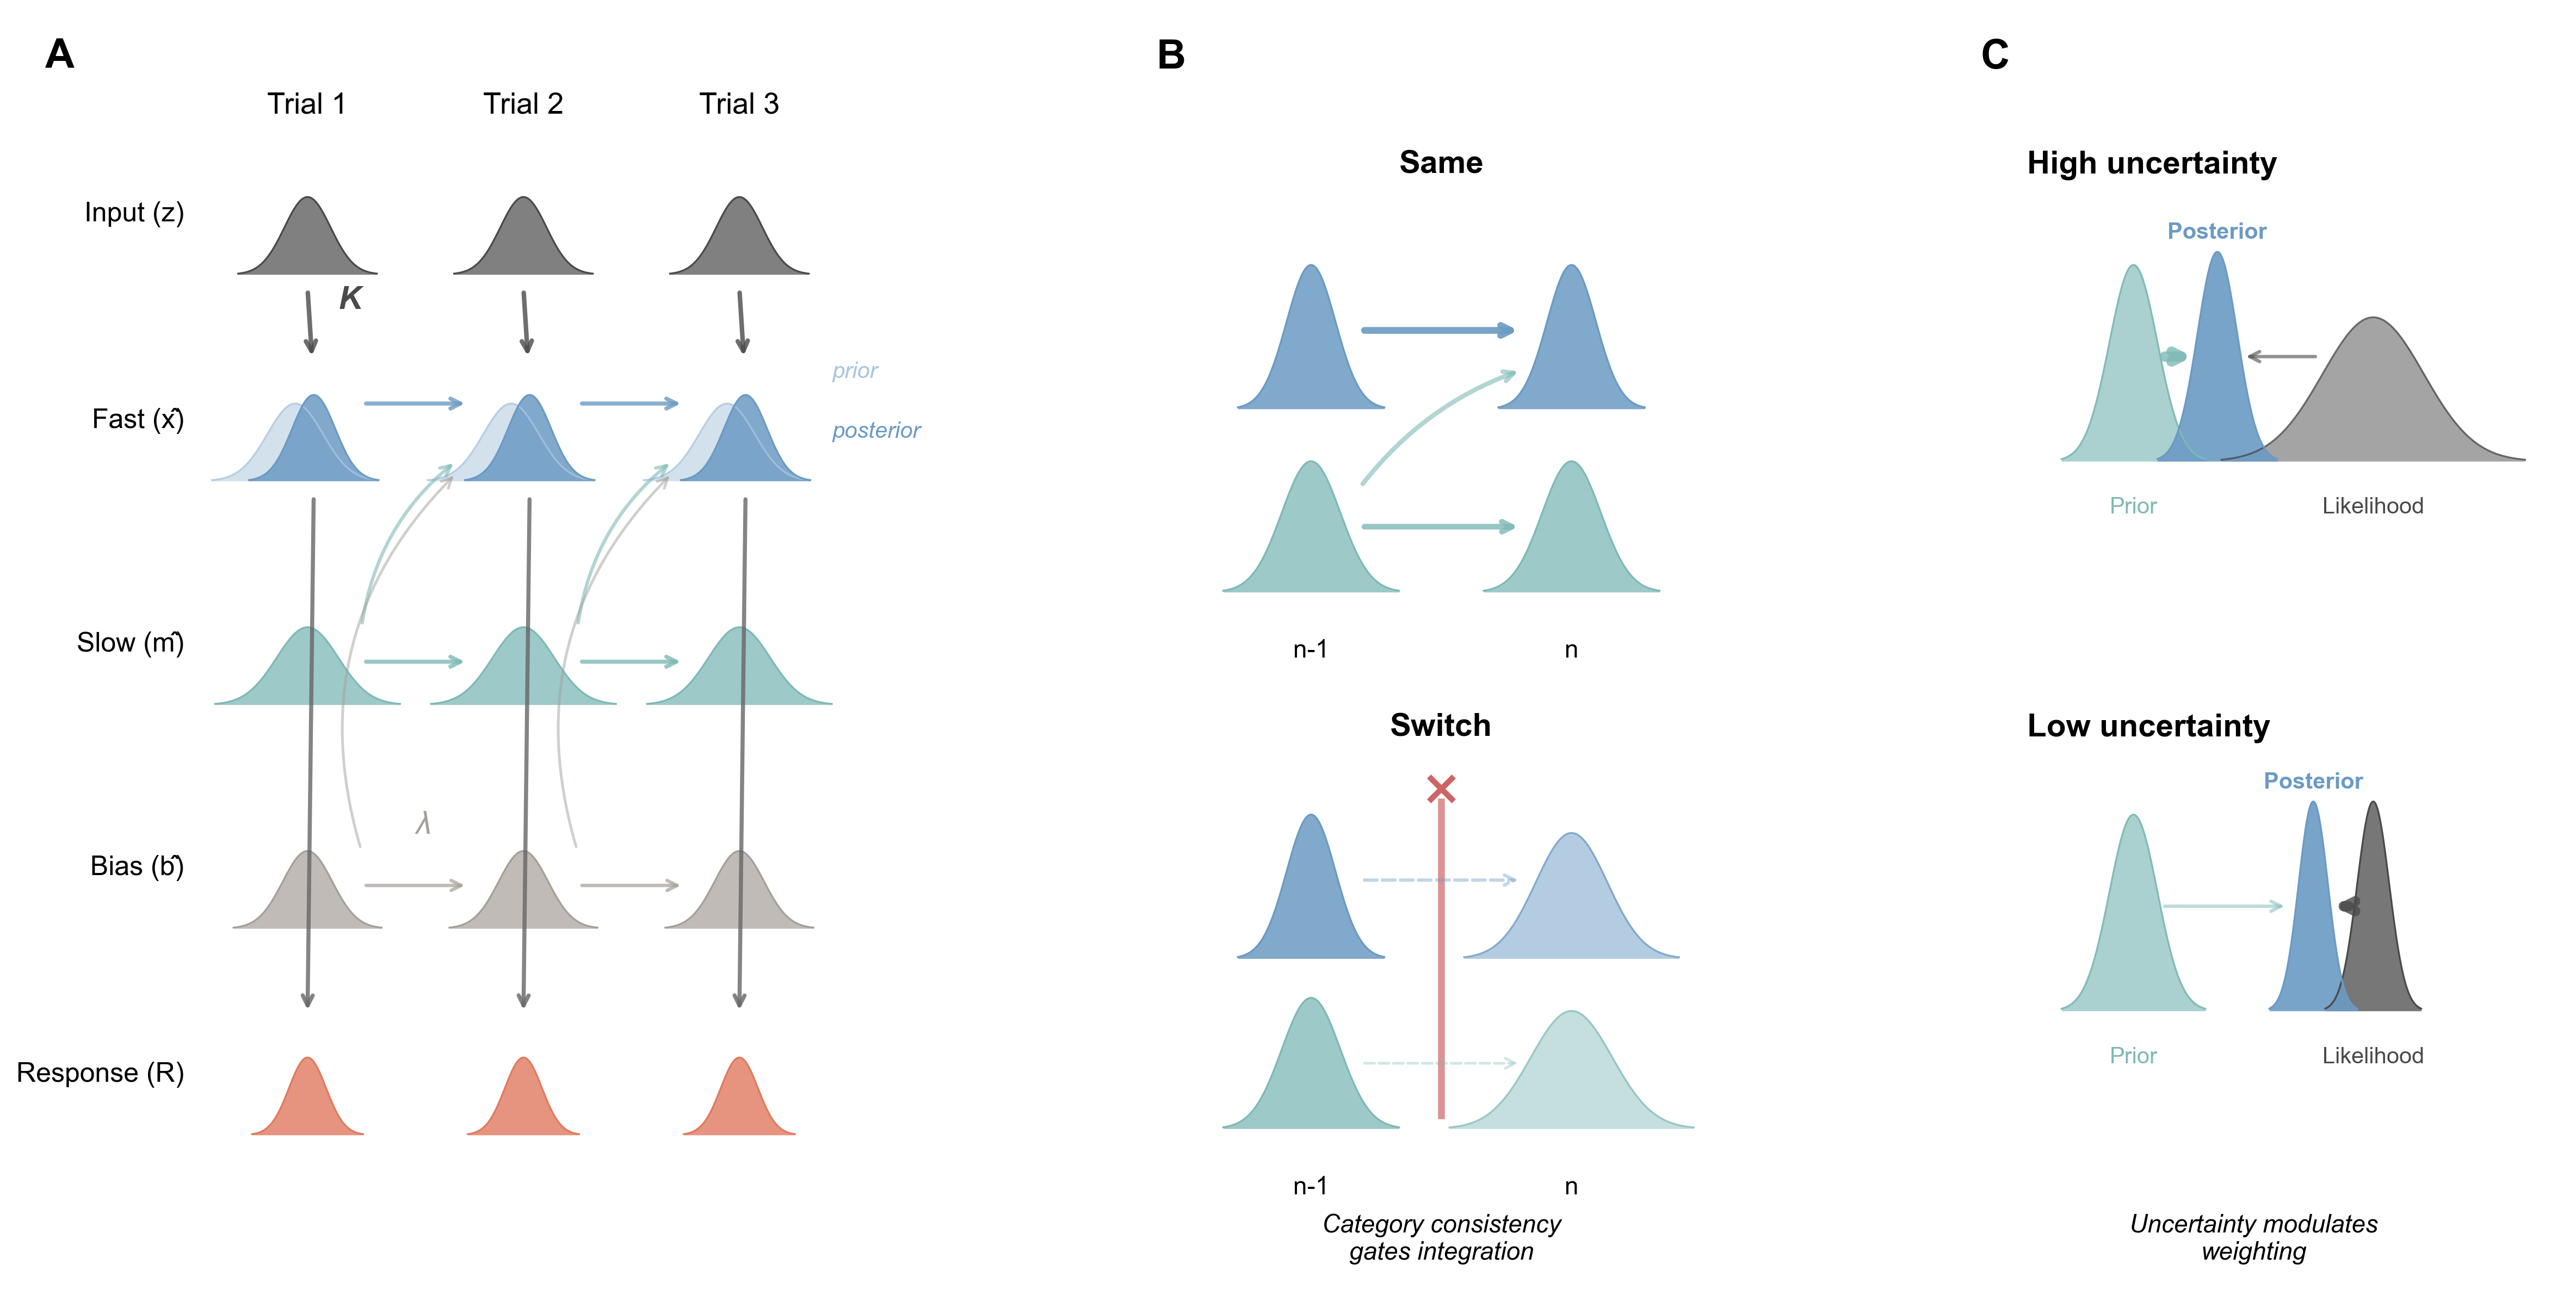

Figure 6: Model schematic loaded from ../manuscript/figures/fig_model_schematic.png


In [9]:
# Figure 6: Model Schematic (generated by manuscript/figures/fig_model_schematic.ipynb)
from IPython.display import Image, display

schematic_path = FIG_DIR / 'fig_model_schematic.png'
if schematic_path.exists():
    display(Image(filename=str(schematic_path), width=900))
    print(f"Figure 6: Model schematic loaded from {schematic_path}")
else:
    print(f"Model schematic not found at {schematic_path}")
    print("Run manuscript/figures/fig_model_schematic.ipynb first to generate it.")

In [ ]:
# Read-only model-result helpers (no fitting, no Kalman/PPC simulation)
C_AXIS = {
    'C0': {'name': 'No coherence modulation', 'description': 'Constant Q/R'},
    'C1': {'name': 'Q1 coherence modulation', 'description': 'Fast-state process noise depends on coherence'},
    'C2': {'name': 'Q2 coherence modulation', 'description': 'Slow-state process noise depends on coherence'},
    'C3': {'name': 'Q3 coherence modulation', 'description': 'Bias-state process noise depends on coherence'},
    'C4': {'name': 'R coherence modulation', 'description': 'Observation noise depends on coherence'},
}
for _i in range(5, 15):
    C_AXIS[f'C{_i}'] = {'name': f'Coherence model C{_i}', 'description': 'See model_fits.csv/model_ranking.csv'}
S_AXIS = {
    'S0': {'name': 'Baseline', 'description': 'No switch-specific reset'},
    'S1': {'name': 'x_reset', 'description': 'Switch reset of state mean'},
    'S2': {'name': 'k_reset', 'description': 'Switch reset of Kalman gain/covariance'},
}
B_AXIS = {
    'B0': {'name': 'No serial bias', 'description': 'No bias state contribution', 'F_02': 0.0, 'response_bias': False},
    'B1': {'name': 'B1', 'description': 'Bias-state transition variant', 'F_02': 0.0, 'response_bias': True},
    'B2': {'name': 'B2', 'description': 'Best-supported bias-state response component', 'F_02': 1.0, 'response_bias': True},
}
N_MODELS = 135

def _axis_id(model_id, prefix):
    for part in str(model_id).split('_'):
        if part.startswith(prefix):
            return part
    return None

def _ranking_source(results=None):
    # Prefer the saved public ranking table. This is the canonical reprocessed-fit
    # output for the public release; do not recompute winners from stale/full fit rows.
    if 'model_ranking' in globals() and model_ranking is not None:
        src = model_ranking.copy()
        rename = {'mean_AIC': 'AIC_mean', 'mean_BIC': 'BIC_mean', 'mean_RMSE': 'RMSE_mean', 'n_subjects': 'n'}
        return src.rename(columns=rename)
    if results is None:
        raise ValueError('No saved model ranking loaded')
    sub = results[(results.get('success', True) == True)].copy()
    return (sub.groupby(['exp', 'model_id', 'model_name'], dropna=False)
              .agg(AIC_mean=('AIC', 'mean'), BIC_mean=('BIC', 'mean'), RMSE_mean=('RMSE', 'mean'), n=('AIC', 'size'))
              .reset_index())

def get_best_model(results, exp_num, criterion='AIC'):
    ranking = _ranking_source(results)
    sub_rank = ranking[ranking['exp'] == exp_num].copy()
    if sub_rank.empty:
        raise ValueError(f'No saved ranking for experiment {exp_num}')
    best = sub_rank.sort_values(f'{criterion}_mean' if f'{criterion}_mean' in sub_rank.columns else 'delta_AIC').iloc[0]
    best_id = best['model_id']
    best_name = best.get('model_name', best_id)
    sub = results[(results['exp'] == exp_num) & (results['model_id'] == best_id)].copy()
    return best_name, sub

def rank_models(results, exp_num, criterion='AIC'):
    ranking = _ranking_source(results)
    sub = ranking[ranking['exp'] == exp_num].copy()
    sort_col = f'{criterion}_mean' if f'{criterion}_mean' in sub.columns else 'delta_AIC'
    return sub.sort_values(sort_col).reset_index(drop=True)

def compare_axes(results, exp_num):
    sub = rank_models(results, exp_num).copy()
    if 'c_id' not in sub.columns:
        sub['c_id'] = sub['model_id'].map(lambda x: _axis_id(x, 'C'))
    if 's_id' not in sub.columns:
        sub['s_id'] = sub['model_id'].map(lambda x: _axis_id(x, 'S'))
    if 'b_id' not in sub.columns:
        sub['b_id'] = sub['model_id'].map(lambda x: _axis_id(x, 'B'))
    return {
        'by_c': sub.groupby('c_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
        'by_s': sub.groupby('s_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
        'by_b': sub.groupby('b_id').agg(AIC_mean=('AIC_mean', 'mean'), BIC_mean=('BIC_mean', 'mean')),
    }

print(f'Read-only Kalman model helpers loaded for {N_MODELS} saved-model grid.')
print('This notebook reads included CSV outputs; it does not fit models or run the Kalman filter.')

# Load saved model fitting results; no fitting/filtering is performed here.
MODEL_DIR = Path('../results/kalman_model_fits')
CHECK_DIR = Path('../results/kalman_model_checks')
results_df = pd.read_csv(MODEL_DIR / 'model_fits.csv')
print(f"Loaded saved model results: {len(results_df):,} fits")
print(f"  Exp1: {len(results_df[results_df['exp'] == 1]):,} fits")
print(f"  Exp2: {len(results_df[results_df['exp'] == 2]):,} fits")
MODEL_LOADED = True

# Prepare observed-data table for panels that overlay observed data with saved predictions.
same_set = {'HH', 'LL'}
exp1_model = (df1.assign(exp=1, Structure=lambda x: np.where(x['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
              .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction', 'curCoherence': 'coherence', 'subID': 'Sub'})
              .astype({'coherence': float, 'Sub': int}))
exp2_model = (df2.assign(exp=2, Structure=lambda x: np.where(x['TransitionType'].isin(same_set), 'Repeat', 'Switch'))
              .rename(columns={'curDur': 'Duration', 'curBias': 'Bias', 'rpr': 'Reproduction', 'curCoherence': 'coherence', 'subID': 'Sub'})
              .astype({'coherence': float, 'Sub': int}))
df_model = pd.concat([exp1_model, exp2_model], ignore_index=True)[['Sub', 'exp', 'trial_num', 'coherence', 'Structure', 'Duration', 'Bias', 'Reproduction']]
df_model = df_model.sort_values(['Sub', 'exp', 'trial_num'])
df_model['preDur'] = df_model.groupby(['Sub', 'exp'])['Duration'].shift(1)

best_exp1, best_data_1 = get_best_model(results_df, exp_num=1, criterion='AIC')
best_exp2, best_data_2 = get_best_model(results_df, exp_num=2, criterion='AIC')
print(f'Best Exp1: {best_exp1}')
print(f'Best Exp2: {best_exp2}')

---
## Figure 7: Model Comparison Table

AIC/BIC values across the compositional Kalman model space.

In [11]:
# Figure 7: Model Comparison - Axis Comparison
if MODEL_LOADED:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    for row, exp_num in enumerate([1, 2]):
        comparison = compare_axes(results_df, exp_num=exp_num)
        
        # C-axis (Coherence Modulation)
        ax = axes[row, 0]
        c_data = comparison['by_c'].sort_values('AIC_mean')
        colors = ['#2ca02c' if 'Q1' in C_AXIS[c]['name'] else '#1f77b4' for c in c_data.index]
        ax.barh(range(len(c_data)), c_data['AIC_mean'], color=colors, alpha=0.7)
        ax.set_yticks(range(len(c_data)))
        ax.set_yticklabels([f"{c} ({C_AXIS[c]['name']})" for c in c_data.index], fontsize=9)
        ax.set_xlabel('Mean AIC')
        ax.set_title(f'Exp {exp_num}: C-Axis (Coherence)', fontweight='bold')
        ax.invert_yaxis()
        despine(ax)
        
        # S-axis (Switch Effect)
        ax = axes[row, 1]
        s_data = comparison['by_s'].sort_values('AIC_mean')
        ax.barh(range(len(s_data)), s_data['AIC_mean'], color='#ff7f0e', alpha=0.7)
        ax.set_yticks(range(len(s_data)))
        ax.set_yticklabels([f"{s} ({S_AXIS[s]['name']})" for s in s_data.index], fontsize=10)
        ax.set_xlabel('Mean AIC')
        ax.set_title(f'Exp {exp_num}: S-Axis (Switch)', fontweight='bold')
        ax.invert_yaxis()
        despine(ax)
        
        # B-axis (Bias Mechanism)
        ax = axes[row, 2]
        b_data = comparison['by_b'].sort_values('AIC_mean')
        ax.barh(range(len(b_data)), b_data['AIC_mean'], color='#9467bd', alpha=0.7)
        ax.set_yticks(range(len(b_data)))
        ax.set_yticklabels([f"{b} ({B_AXIS[b]['name']})" for b in b_data.index], fontsize=10)
        ax.set_xlabel('Mean AIC')
        ax.set_title(f'Exp {exp_num}: B-Axis (Bias)', fontweight='bold')
        ax.invert_yaxis()
        despine(ax)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig7_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIG_DIR / 'fig7_model_comparison.pdf', bbox_inches='tight')
    plt.show()
    print(f"Figure 7 saved to {FIG_DIR}")
else:
    print("Skipping Figure 7 - model results not loaded")

Figure 7 saved to ../manuscript/figures


---
## Figure 8: Best Model Parameters

- **Figure 8A**: Experiment 1 best model - all fitted parameters
- **Figure 8B**: Experiment 2 best model - all fitted parameters

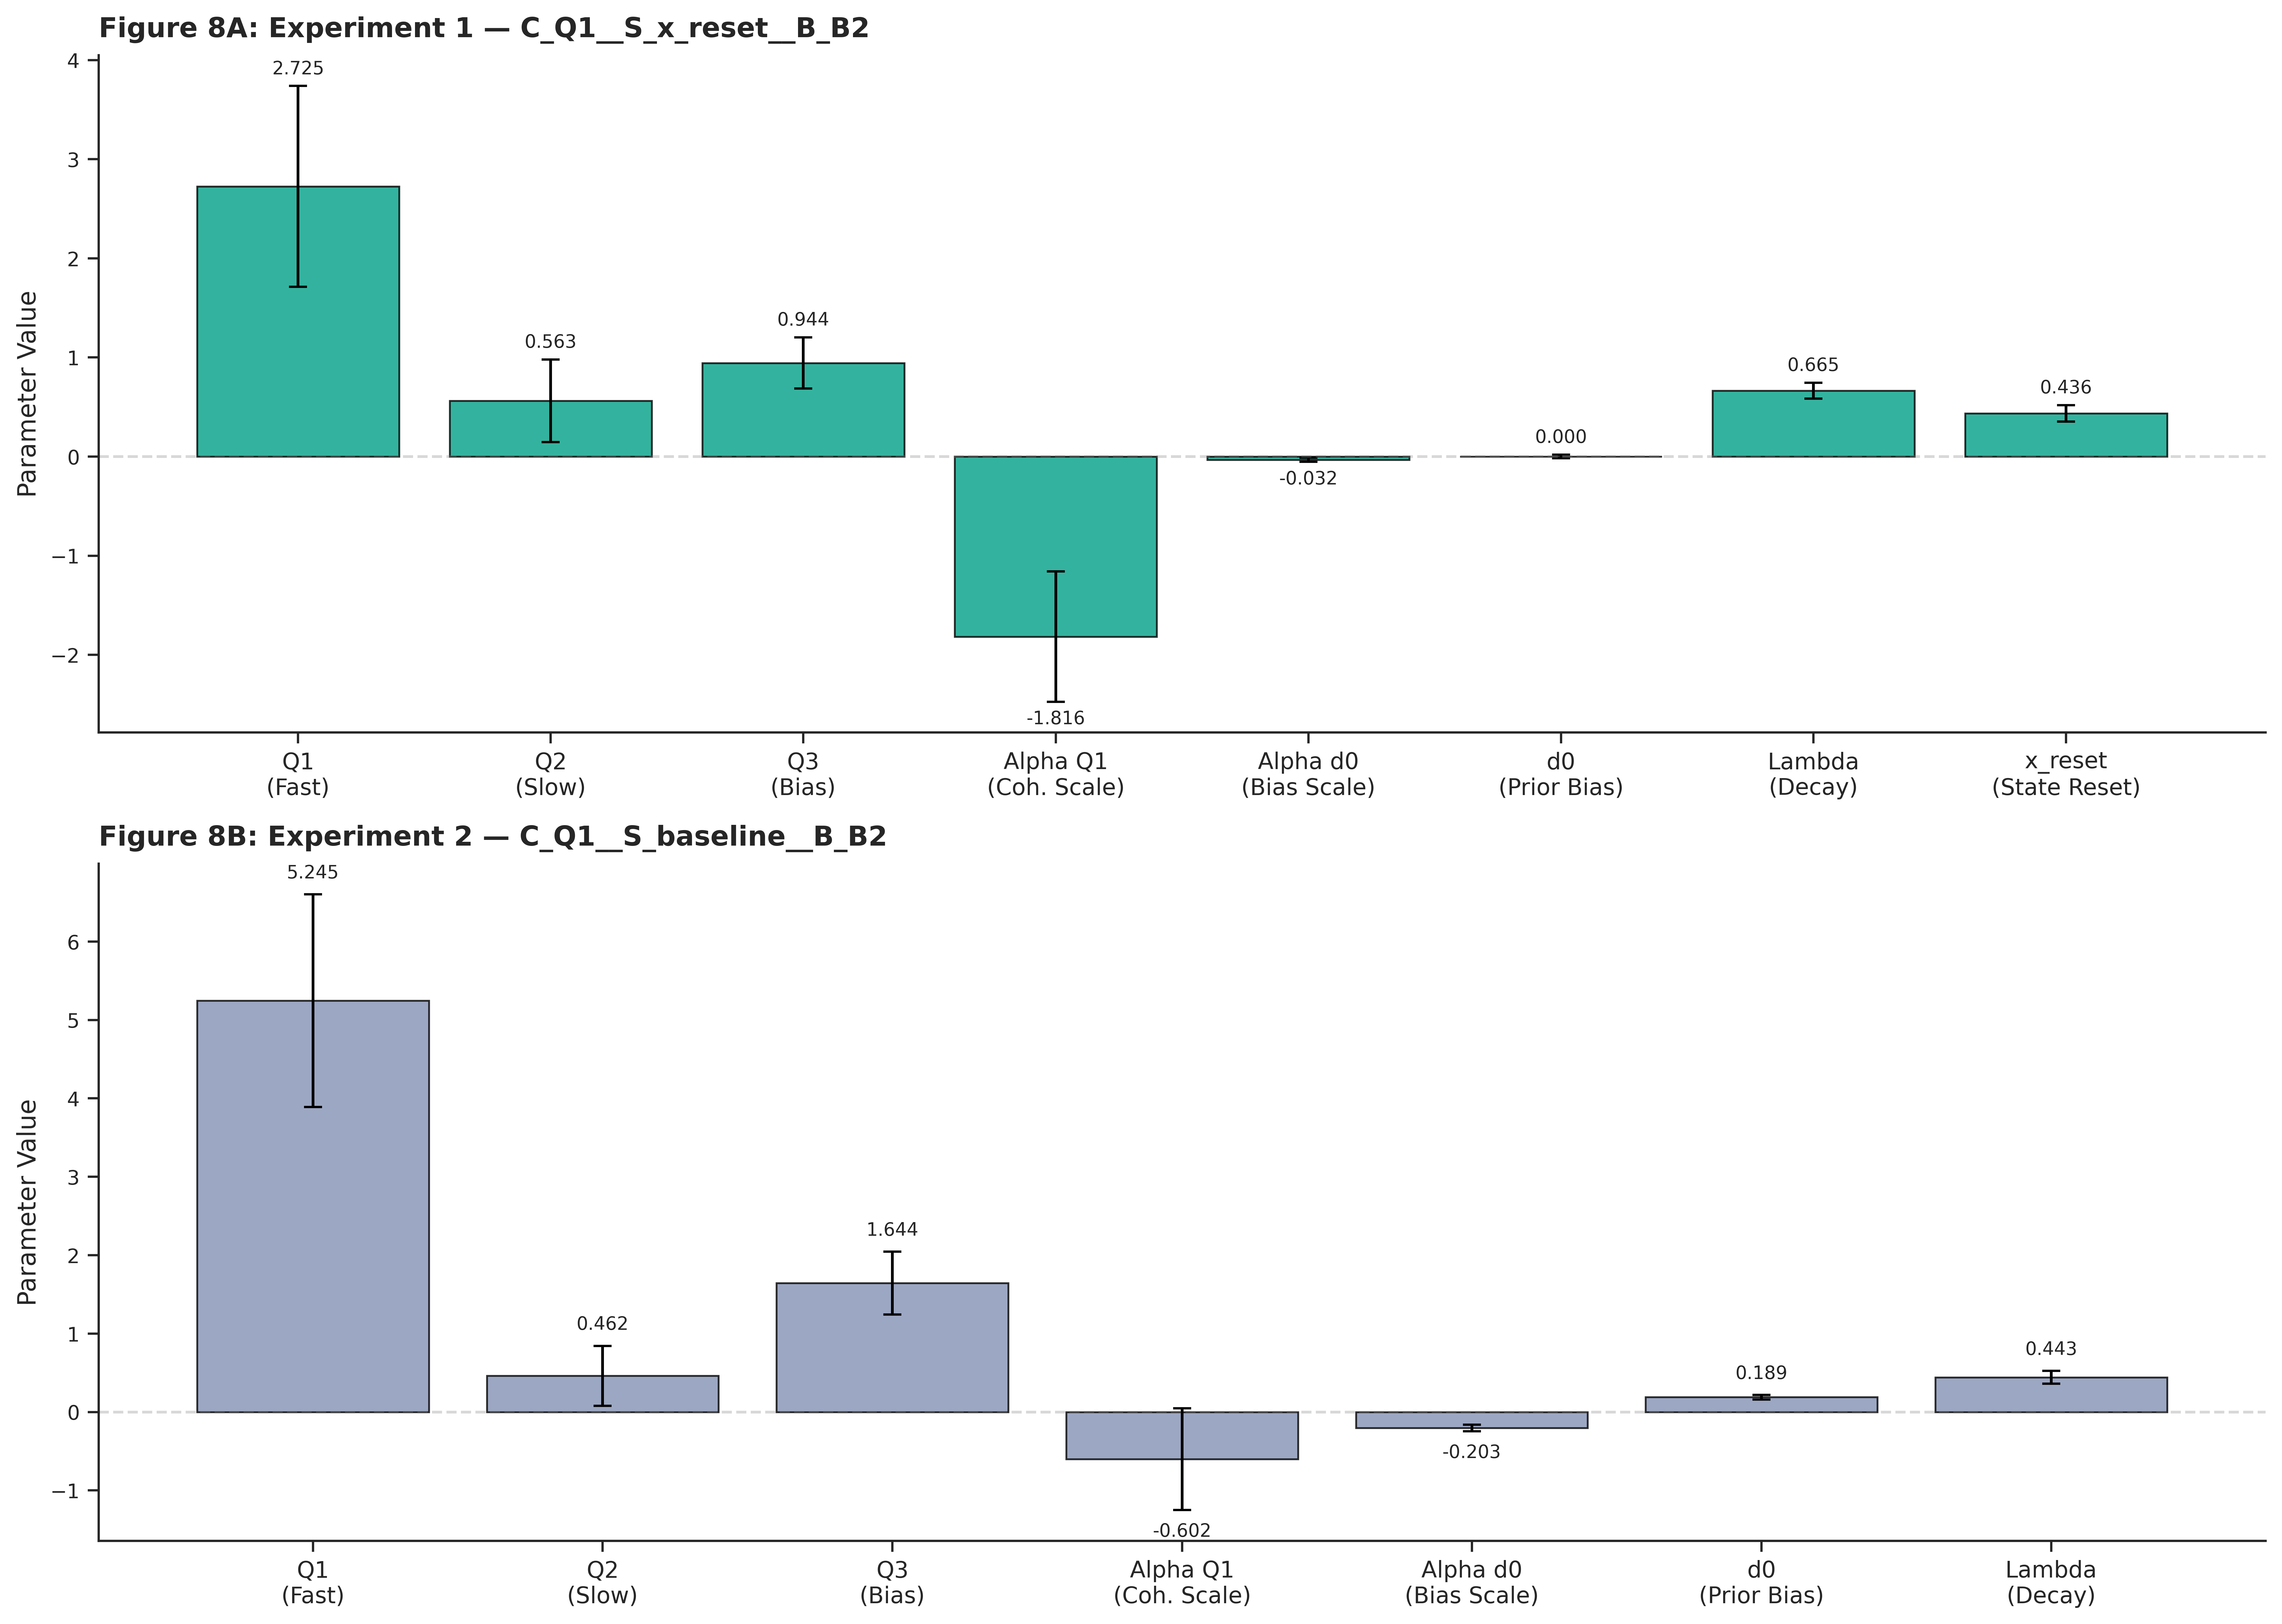


Best Models Summary:

Experiment 1: C_Q1__S_x_reset__B_B2
  N subjects: 22
  Fitted parameters:
    q1: 2.7252 +/- 1.0131
    q2: 0.5627 +/- 0.4159
    q3: 0.9441 +/- 0.2579
    alpha_q1: -1.8160 +/- 0.6567
    alpha_d0: -0.0318 +/- 0.0211
    d0: 0.0004 +/- 0.0180
    lambda: 0.6650 +/- 0.0804
    x_reset: 0.4357 +/- 0.0838

Experiment 2: C_Q1__S_baseline__B_B2
  N subjects: 22
  Fitted parameters:
    q1: 5.2450 +/- 1.3563
    q2: 0.4621 +/- 0.3815
    q3: 1.6437 +/- 0.4019
    alpha_q1: -0.6025 +/- 0.6485
    alpha_d0: -0.2032 +/- 0.0415
    d0: 0.1888 +/- 0.0295
    lambda: 0.4426 +/- 0.0815

Figure 8 saved to ../manuscript/figures


In [12]:
# Figure 8: Best Model Parameters (8A: Exp1, 8B: Exp2)
if MODEL_LOADED:
    # Define fitted parameters and their display names
    # Note: r_low is the only observation noise free parameter
    all_params = {
        'q1': 'Q1\n(Fast)',
        'q2': 'Q2\n(Slow)', 
        'q3': 'Q3\n(Bias)',
        'r_low': 'R\n(Obs. Noise)',
        'alpha_q1': 'Alpha Q1\n(Coh. Scale)',
        'alpha_d0': 'Alpha d0\n(Bias Scale)',
        'd0': 'd0\n(Prior Bias)',
        'lambda': 'Lambda\n(Decay)',
        'x_reset': 'x_reset\n(State Reset)',
        'k_reset': 'k_reset\n(Reset Str.)'
    }
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    for exp_idx, exp_num in enumerate([1, 2]):
        ax = axes[exp_idx]
        best_name, best_data = get_best_model(results_df, exp_num=exp_num)
        color = COLORS['exp1'] if exp_num == 1 else COLORS['exp2']
        
        # Get parameters that exist and have non-NaN values
        valid_params = []
        valid_labels = []
        means = []
        sems = []
        
        for param, label in all_params.items():
            if param in best_data.columns:
                values = best_data[param].dropna()
                if len(values) > 0 and not np.isnan(values.mean()):
                    valid_params.append(param)
                    valid_labels.append(label)
                    means.append(values.mean())
                    sems.append(values.std() / np.sqrt(len(values)))
        
        x = np.arange(len(valid_params))
        
        # Plot bars
        bars = ax.bar(x, means, yerr=sems, capsize=4, 
                      color=color, alpha=0.8, edgecolor='black', lw=0.8)
        
        # Add value labels on bars
        max_val = max(means) if means else 1
        for i, (mean_val, sem_val) in enumerate(zip(means, sems)):
            y_offset = max_val * 0.03
            if mean_val >= 0:
                ax.text(i, mean_val + sem_val + y_offset, f'{mean_val:.3f}', 
                       ha='center', va='bottom', fontsize=8)
            else:
                ax.text(i, mean_val - sem_val - y_offset, f'{mean_val:.3f}', 
                       ha='center', va='top', fontsize=8)
        
        ax.set_xticks(x)
        ax.set_xticklabels(valid_labels, fontsize=10)
        ax.set_ylabel('Parameter Value', fontsize=11)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
        
        # Title with model name
        panel_label = 'A' if exp_num == 1 else 'B'
        ax.set_title(f'Figure 8{panel_label}: Experiment {exp_num} — {best_name}', 
                    loc='left', fontweight='bold', fontsize=12)
        despine(ax)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig8_parameters.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIG_DIR / 'fig8_parameters.pdf', bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("Best Models Summary:")
    print("="*60)
    for exp_num in [1, 2]:
        best_name, best_data = get_best_model(results_df, exp_num=exp_num)
        print(f"\nExperiment {exp_num}: {best_name}")
        print(f"  N subjects: {len(best_data)}")
        # Show fitted parameters
        print(f"  Fitted parameters:")
        for param, label in all_params.items():
            if param in best_data.columns:
                values = best_data[param].dropna()
                if len(values) > 0 and not np.isnan(values.mean()):
                    print(f"    {param}: {values.mean():.4f} +/- {values.std()/np.sqrt(len(values)):.4f}")
    
    print(f"\nFigure 8 saved to {FIG_DIR}")
else:
    print("Skipping Figure 8 - model results not loaded")

---
## Figure 9: CTI & SDI Recovery

In [ ]:
# Load saved PPC / trial-level prediction outputs (read-only; no simulation)
CHECK_DIR = root / 'results' / 'kalman_model_checks'
ppc_subject_metrics = pd.read_csv(CHECK_DIR / 'winner_ppc_subject_metrics.csv')
ppc_summary = pd.read_csv(CHECK_DIR / 'winner_ppc_summary.csv')
trial_predictions = pd.read_csv(CHECK_DIR / 'winner_ppc_trial_predictions.csv')
behavioral_effects_subject = pd.read_csv(CHECK_DIR / 'winner_behavioral_effects_subject.csv')
behavioral_effects_summary = pd.read_csv(CHECK_DIR / 'winner_behavioral_effect_summary.csv')

ppc_results = {}
for exp_num in sorted(ppc_subject_metrics['exp'].unique()):
    merged = (ppc_subject_metrics[ppc_subject_metrics['exp'] == exp_num]
              .rename(columns={
                  'cti_obs': 'CTI_obs', 'cti_pred': 'CTI_sim',
                  'sdi_obs': 'SDI_obs', 'sdi_pred': 'SDI_sim',
              })
              .copy())
    summary_row = ppc_summary[ppc_summary['exp'] == exp_num].iloc[0]
    ppc_results[int(exp_num)] = {
        'merged': merged,
        'CTI_r': summary_row['cti_r'],
        'SDI_r': summary_row['sdi_r'],
        'CTI_rec': summary_row['cti_mean_pred'] / summary_row['cti_mean_obs'] * 100,
        'SDI_rec': summary_row['sdi_mean_pred'] / summary_row['sdi_mean_obs'] * 100,
        'model': summary_row['model_name'],
    }

print('Loaded saved PPC subject metrics and trial-level predictions.')
print('No PPC simulation/Kalman filtering is run in this notebook.')
for exp_num, res in ppc_results.items():
    print(f"  Exp {exp_num}: {res['model']} | CTI r={res['CTI_r']:.3f}, SDI r={res['SDI_r']:.3f}")

In [ ]:
# Saved PPC summary (read-only; no simulation)
display(ppc_summary)

---
## Figure 10: SDI vs CTI (Combined Exp 1 & 2)

Observed SDI vs CTI relationship for each subject in both experiments.

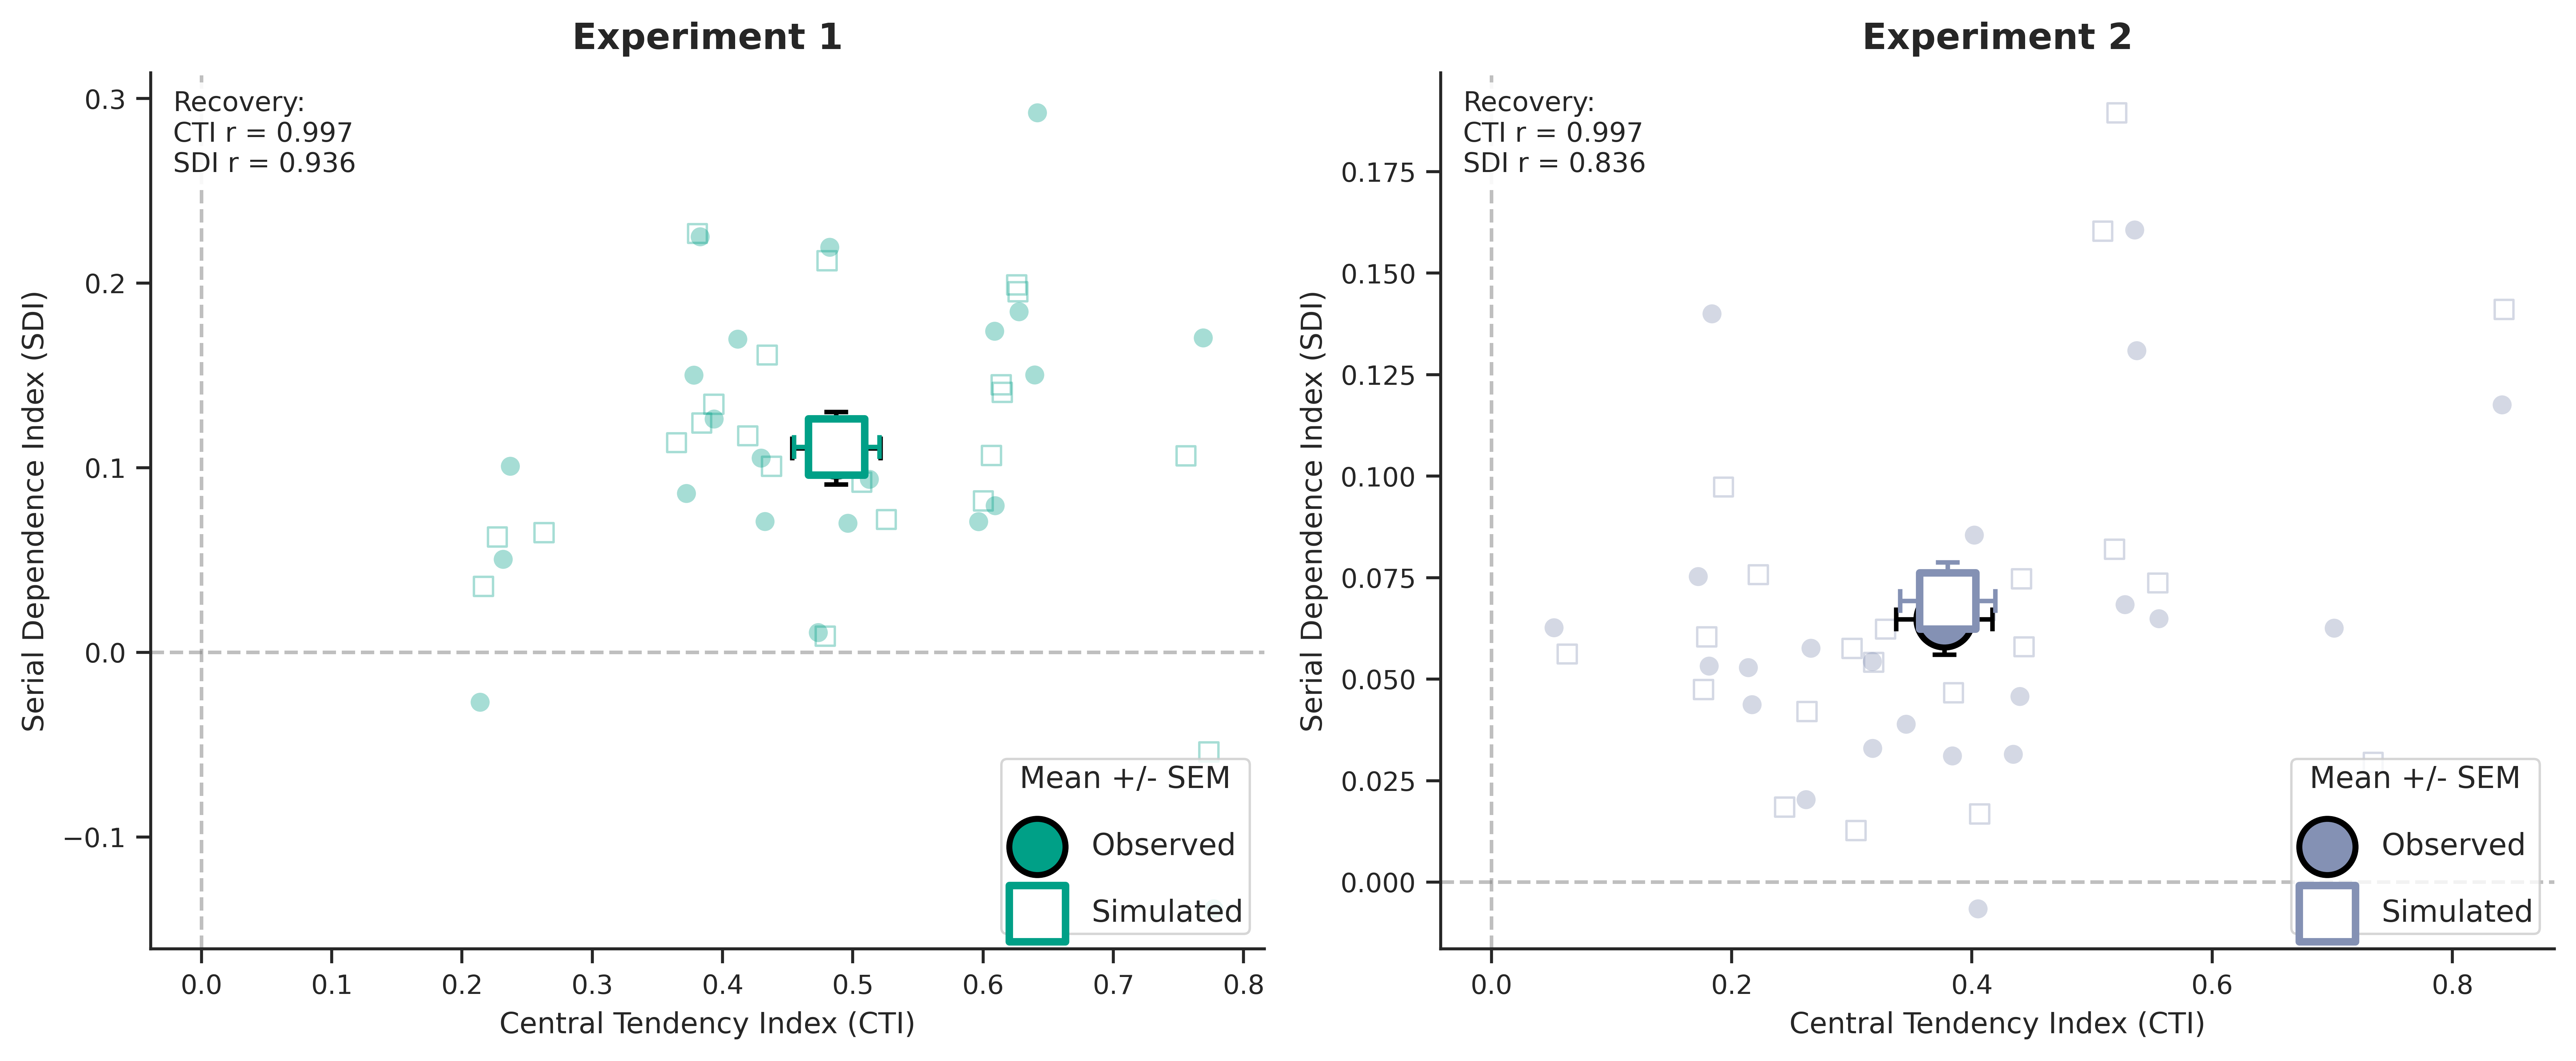

Figure 10 saved to ../manuscript/figures


In [15]:
# Figure 10: SDI vs CTI (Both experiments) - with mean points
if MODEL_LOADED and ppc_results:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, exp_num in enumerate([1, 2]):
        ax = axes[idx]
        
        if exp_num in ppc_results:
            merged = ppc_results[exp_num]['merged']
            res = ppc_results[exp_num]
            color = COLORS['exp1'] if exp_num == 1 else COLORS['exp2']
            
            # Observed - individual points (smaller, lighter)
            valid = merged.dropna(subset=['CTI_obs', 'SDI_obs'])
            x_obs = valid['CTI_obs']
            y_obs = valid['SDI_obs']
            
            ax.scatter(x_obs, y_obs, s=40, alpha=0.35, 
                       color=color, edgecolors='none', label='_nolegend_')
            
            # Simulated - individual points (smaller, lighter, different marker)
            valid_sim = merged.dropna(subset=['CTI_sim', 'SDI_sim'])
            x_sim = valid_sim['CTI_sim']
            y_sim = valid_sim['SDI_sim']
            
            ax.scatter(x_sim, y_sim, s=40, alpha=0.35,
                       facecolors='none', edgecolors=color, lw=0.8, 
                       marker='s', label='_nolegend_')
            
            # ========== MEAN POINTS (larger, more prominent) ==========
            # Observed mean
            obs_mean_cti = x_obs.mean()
            obs_mean_sdi = y_obs.mean()
            ax.scatter(obs_mean_cti, obs_mean_sdi, s=350, 
                       color=color, edgecolors='black', lw=2,
                       marker='o', zorder=10, label='Observed')
            
            # Simulated mean
            sim_mean_cti = x_sim.mean()
            sim_mean_sdi = y_sim.mean()
            ax.scatter(sim_mean_cti, sim_mean_sdi, s=350,
                       facecolors='white', edgecolors=color, lw=2.5,
                       marker='s', zorder=10, label='Simulated')
            
            # Add error bars for means (SEM)
            obs_sem_cti = x_obs.std() / np.sqrt(len(x_obs))
            obs_sem_sdi = y_obs.std() / np.sqrt(len(y_obs))
            sim_sem_cti = x_sim.std() / np.sqrt(len(x_sim))
            sim_sem_sdi = y_sim.std() / np.sqrt(len(y_sim))
            
            ax.errorbar(obs_mean_cti, obs_mean_sdi, 
                       xerr=obs_sem_cti, yerr=obs_sem_sdi,
                       color='black', capsize=4, capthick=1.5, lw=1.5, zorder=9, fmt='none')
            ax.errorbar(sim_mean_cti, sim_mean_sdi,
                       xerr=sim_sem_cti, yerr=sim_sem_sdi,
                       color=color, capsize=4, capthick=1.5, lw=1.5, zorder=9, fmt='none')
            
            # Display recovery correlations
            cti_r = res['CTI_r']
            sdi_r = res['SDI_r']
            
            ax.text(0.02, 0.98, f'Recovery:\nCTI r = {cti_r:.3f}\nSDI r = {sdi_r:.3f}', 
                   transform=ax.transAxes, fontsize=9, va='top', ha='left',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='none'))
        
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Central Tendency Index (CTI)')
        ax.set_ylabel('Serial Dependence Index (SDI)')
        ax.set_title(f'Experiment {exp_num}', fontweight='bold', fontsize=12)
        
        # Clean legend - only show mean points
        ax.legend(frameon=True, fontsize=10, loc='lower right', 
                  title='Mean +/- SEM', title_fontsize=10, labelspacing=1.25)
        despine(ax)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig10_sdi_vs_cti.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIG_DIR / 'fig10_sdi_vs_cti.pdf', bbox_inches='tight')
    plt.show()
    print(f"Figure 10 saved to {FIG_DIR}")
else:
    print("Skipping Figure 10 - prerequisites not available")

---
## Figure 8: Trial-Level Serial Dependence Pattern

Compare observed vs. simulated serial dependence (Bias ~ previous duration) by condition:
- **Experiment 1**: Same vs. Switch (task structure)
- **Experiment 2**: Low vs. High coherence (uncertainty)

In [ ]:
# Trial-level serial dependence by condition from saved predictions
def plot_sd_by_condition(data, results_df, exp_num, model_name, ax=None):
    """Plot observed vs saved model-predicted serial dependence by condition.

    Uses results/kalman_model_checks/winner_ppc_trial_predictions.csv.
    Does not generate new simulated responses or run a Kalman filter.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    exp_data = trial_predictions[trial_predictions['exp'] == exp_num].copy()
    if exp_data.empty:
        return ax
    exp_data = exp_data.sort_values(['Sub', 'trial_num'])
    exp_data['preDur'] = exp_data.groupby('Sub')['Duration'].shift(1)

    if exp_num == 1:
        cond_col = 'Structure'
        conds = ['Repeat', 'Switch'] if 'Repeat' in set(exp_data['Structure'].dropna()) else ['Same', 'Switch']
        colors = [COLORS.get('same', '#4C78A8'), COLORS.get('switch', '#F58518')] if isinstance(COLORS, dict) else ['#4C78A8', '#F58518']
        title_suffix = 'Task Structure'
    else:
        exp_data['coh_cat'] = np.where(exp_data['coherence'] < 0.5, 'Low', 'High')
        cond_col = 'coh_cat'
        conds = ['Low', 'High']
        colors = [COLORS.get('low', '#54A24B'), COLORS.get('high', '#E45756')] if isinstance(COLORS, dict) else ['#54A24B', '#E45756']
        title_suffix = 'Coherence'

    for i, cond in enumerate(conds):
        cond_df = exp_data[exp_data[cond_col] == cond].dropna(subset=['preDur', 'obs_bias', 'pred_bias'])
        if cond_df.empty:
            continue
        obs = cond_df.groupby('preDur')['obs_bias'].agg(['mean', 'sem']).reset_index()
        pred = cond_df.groupby('preDur')['pred_bias'].agg(['mean', 'sem']).reset_index()
        color = colors[i % len(colors)]
        ax.errorbar(obs['preDur'], obs['mean'], yerr=obs['sem'], marker='o', lw=2, color=color, label=f'{cond} observed')
        ax.errorbar(pred['preDur'], pred['mean'], yerr=pred['sem'], marker='s', lw=2, ls='--', color=color, alpha=.75, label=f'{cond} saved prediction')
    ax.axhline(0, color='black', lw=.8, alpha=.5)
    ax.set_xlabel('Previous duration')
    ax.set_ylabel('Bias')
    ax.set_title(f'Exp {exp_num}: {title_suffix}')
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
    return ax

---
# Supplementary Figures

In [17]:
# Compute CTI for supplementary figures (using ABSOLUTE values)
cti_list_1 = []
for (sub_id, trans_type), group in df1.groupby(['subID', 'TransitionType']):
    if len(group) >= 5:
        X = sm.add_constant(group['curDur'])
        y = group['curBias']
        model = sm.OLS(y, X).fit()
        cti_list_1.append({
            'subID': sub_id,
            'TransitionType': trans_type,
            'CTI': np.abs(model.params['curDur']),  # Absolute value
            'intercept': model.params['const']
        })

df_cti_1 = pd.DataFrame(cti_list_1)
df_cti_1['priorCoh'] = df_cti_1['TransitionType'].str[0].map({'H': 'High', 'L': 'Low'})
df_cti_1['curCoh'] = df_cti_1['TransitionType'].str[1].map({'H': 'High', 'L': 'Low'})

cti_list_2 = []
for (sub_id, trans_type), group in df2.groupby(['subID', 'TransitionType']):
    if len(group) >= 5:
        X = sm.add_constant(group['curDur'])
        y = group['curBias']
        model = sm.OLS(y, X).fit()
        cti_list_2.append({
            'subID': sub_id,
            'TransitionType': trans_type,
            'CTI': np.abs(model.params['curDur']),  # Absolute value
            'intercept': model.params['const']
        })

df_cti_2 = pd.DataFrame(cti_list_2)
df_cti_2['priorCoh'] = df_cti_2['TransitionType'].str[0].map({'H': 'High', 'L': 'Low'})
df_cti_2['curCoh'] = df_cti_2['TransitionType'].str[1].map({'H': 'High', 'L': 'Low'})

print("CTI computed for supplementary figures (absolute values)")

CTI computed for supplementary figures (absolute values)


## Figure S1: CTI Detail - Experiment 1

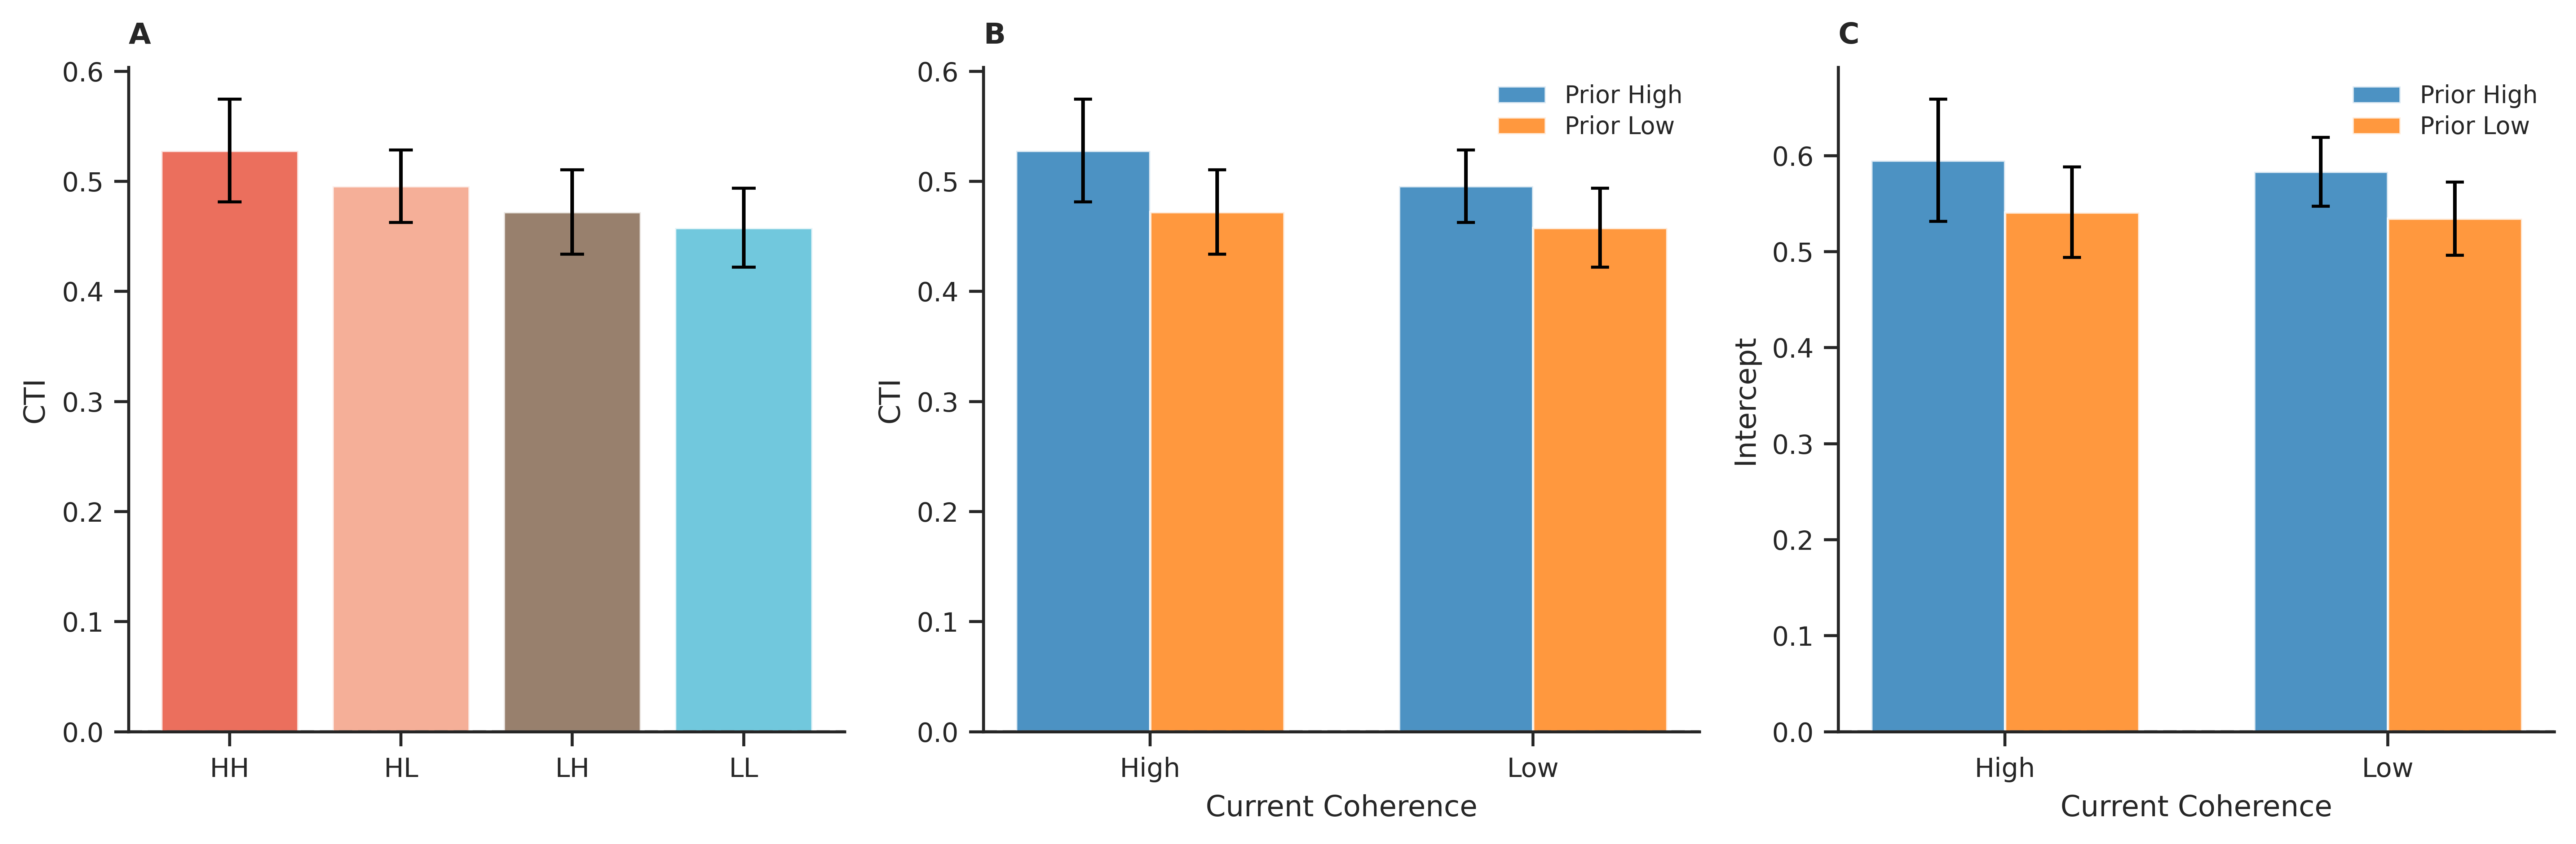

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel A: CTI by transition type
ax = axes[0]
cti_trans = df_cti_1.groupby('TransitionType')['CTI'].agg(['mean', 'sem']).reset_index()
cti_trans = cti_trans.set_index('TransitionType').loc[TRANSITION_ORDER].reset_index()
ax.bar(cti_trans['TransitionType'], cti_trans['mean'], yerr=cti_trans['sem'], capsize=4,
       color=[COLORS[t] for t in cti_trans['TransitionType']], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('CTI')
ax.set_title('A', loc='left', fontweight='bold')
despine(ax)

# Panel B: CTI by prior x current
ax = axes[1]
cti_2x2 = df_cti_1.groupby(['priorCoh', 'curCoh'])['CTI'].agg(['mean', 'sem']).reset_index()
x = np.arange(2)
width = 0.35
for i, prior in enumerate(['High', 'Low']):
    prior_data = cti_2x2[cti_2x2['priorCoh'] == prior]
    prior_data = prior_data.set_index('curCoh').loc[['High', 'Low']].reset_index()
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('CTI')
ax.set_title('B', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
despine(ax)

# Panel C: Intercepts
ax = axes[2]
bias_2x2 = df_cti_1.groupby(['priorCoh', 'curCoh'])['intercept'].agg(['mean', 'sem']).reset_index()
for i, prior in enumerate(['High', 'Low']):
    prior_data = bias_2x2[bias_2x2['priorCoh'] == prior]
    prior_data = prior_data.set_index('curCoh').loc[['High', 'Low']].reset_index()
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Intercept')
ax.set_title('C', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
despine(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figS1_cti_exp1.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure S2: CTI Detail - Experiment 2

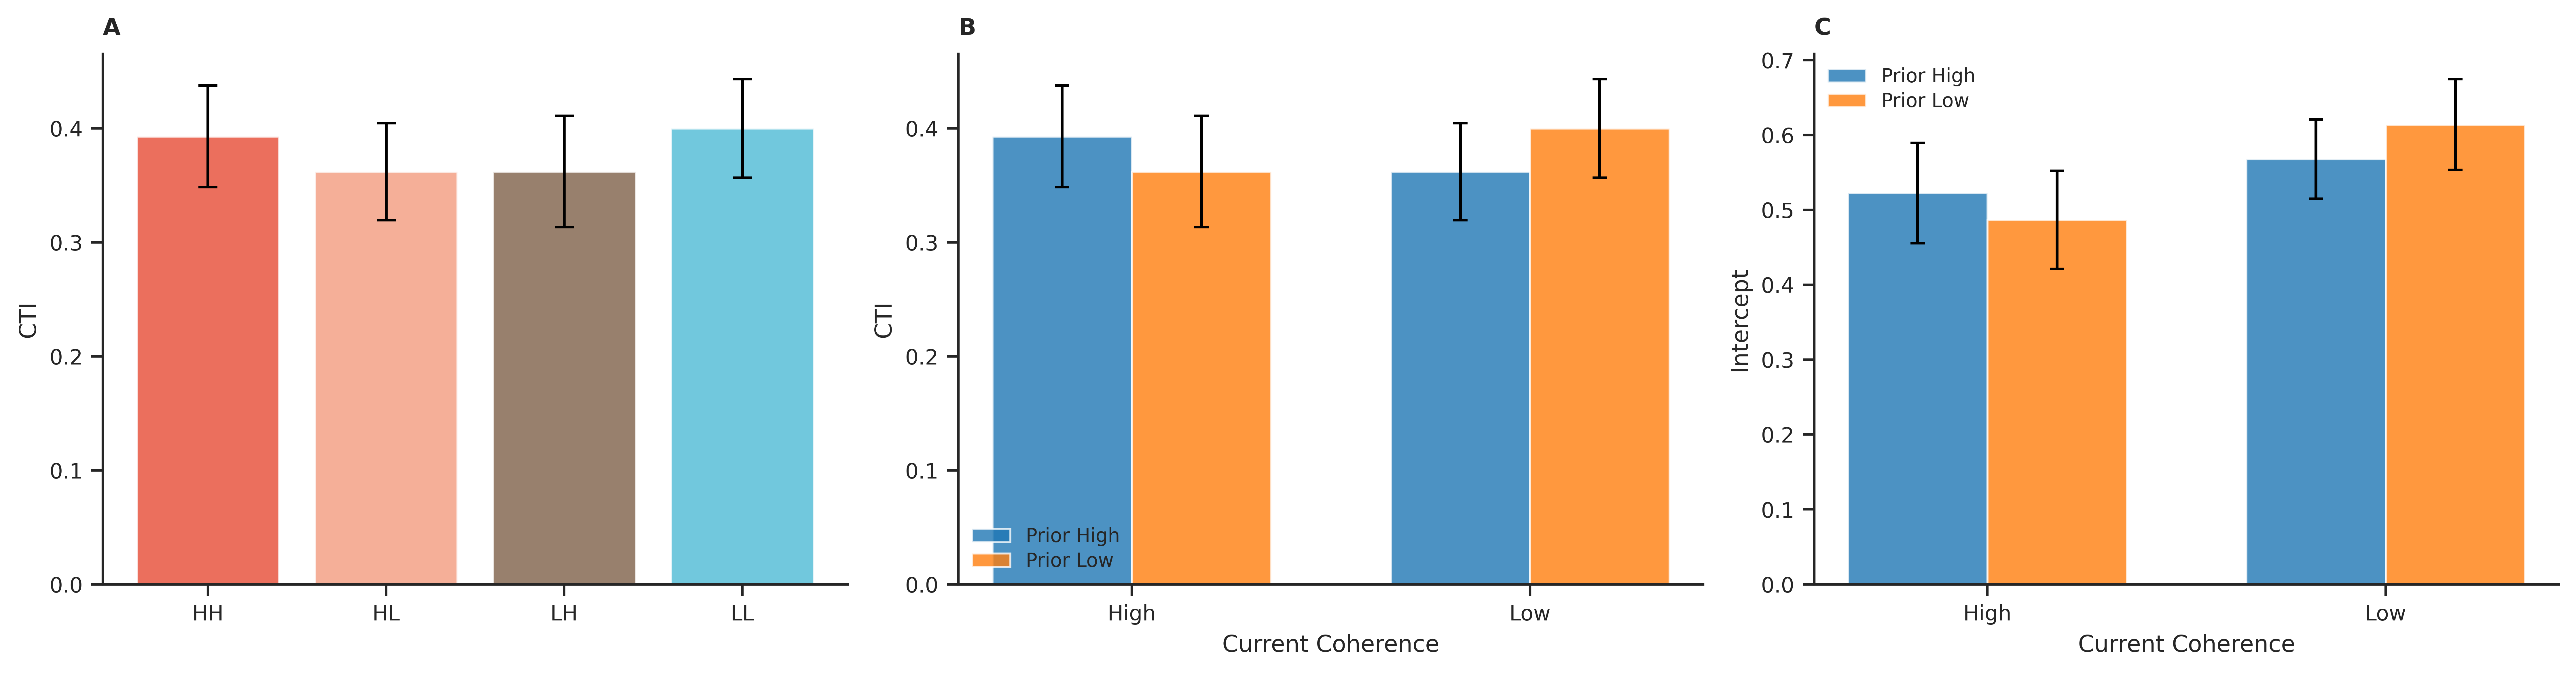

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A: CTI by transition type
ax = axes[0]
cti_trans2 = df_cti_2.groupby('TransitionType')['CTI'].agg(['mean', 'sem']).reset_index()
cti_trans2 = cti_trans2.set_index('TransitionType').loc[TRANSITION_ORDER].reset_index()
ax.bar(cti_trans2['TransitionType'], cti_trans2['mean'], yerr=cti_trans2['sem'], capsize=4,
       color=[COLORS[t] for t in cti_trans2['TransitionType']], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('CTI')
ax.set_title('A', loc='left', fontweight='bold')
despine(ax)

# Panel B: CTI by prior x current
ax = axes[1]
cti_2x2_2 = df_cti_2.groupby(['priorCoh', 'curCoh'])['CTI'].agg(['mean', 'sem']).reset_index()
x = np.arange(2)
width = 0.35
for i, prior in enumerate(['High', 'Low']):
    prior_data = cti_2x2_2[cti_2x2_2['priorCoh'] == prior]
    prior_data = prior_data.set_index('curCoh').loc[['High', 'Low']].reset_index()
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('CTI')
ax.set_title('B', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
despine(ax)

# Panel C: Intercepts
ax = axes[2]
intercept_2x2_2 = df_cti_2.groupby(['priorCoh', 'curCoh'])['intercept'].agg(['mean', 'sem']).reset_index()
for i, prior in enumerate(['High', 'Low']):
    prior_data = intercept_2x2_2[intercept_2x2_2['priorCoh'] == prior]
    prior_data = prior_data.set_index('curCoh').loc[['High', 'Low']].reset_index()
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Intercept')
ax.set_title('C', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8)
despine(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figS2_cti_exp2.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure S3: 10-back Serial Dependence

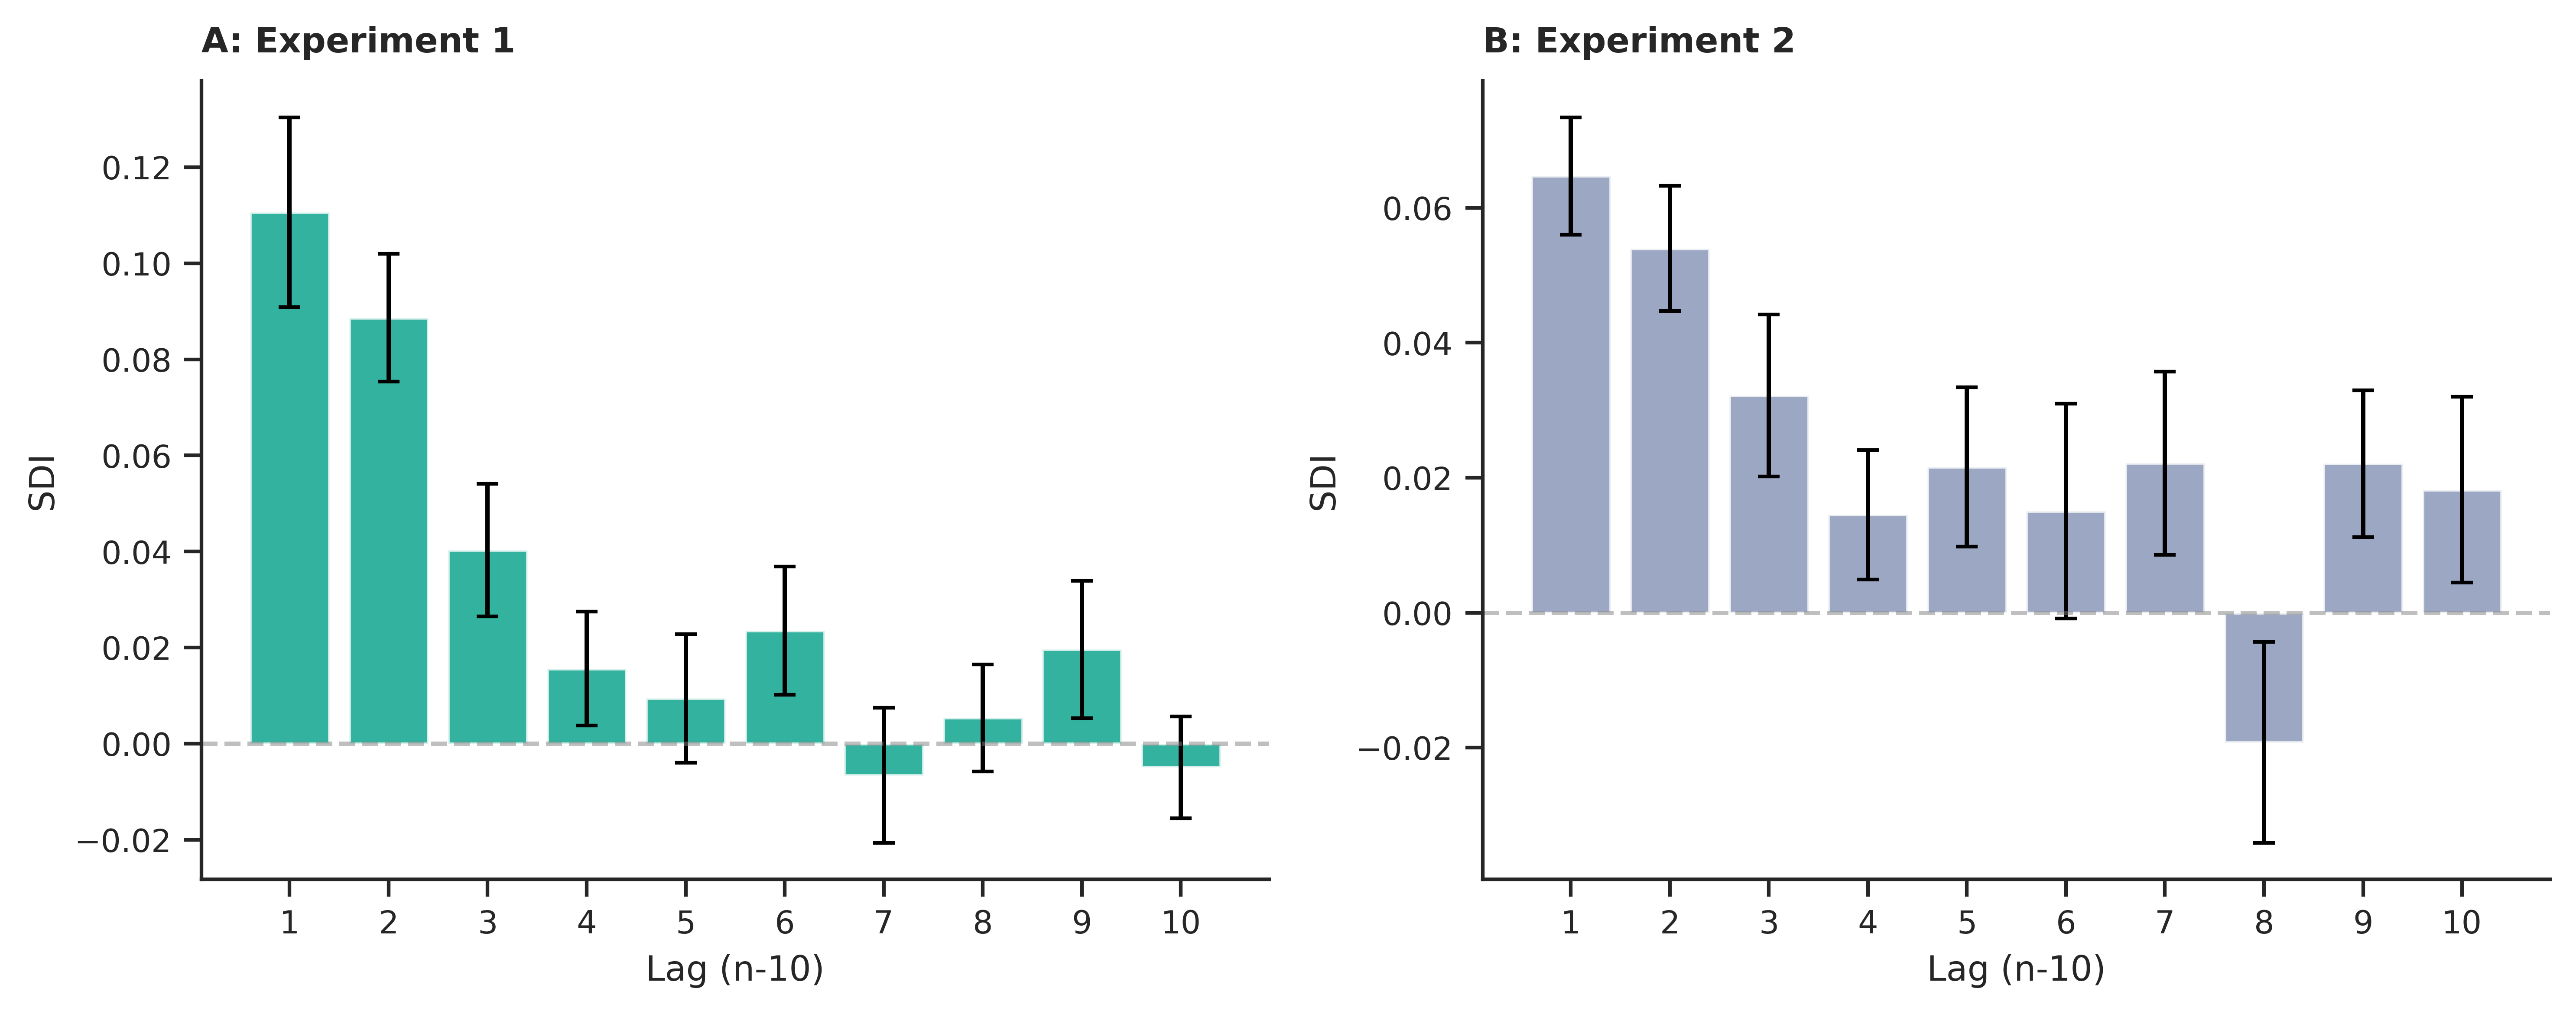

In [20]:
def compute_multilag_sdi(df_exp, max_lag=10):
    df_sorted = df_exp.sort_values(['subID', 'trial_num']).copy()
    for lag in range(1, max_lag + 1):
        df_sorted[f'preDur{lag}back'] = df_sorted.groupby('subID')['curDur'].shift(lag)
    
    results = []
    for lag in range(1, max_lag + 1):
        var = f'preDur{lag}back'
        slopes = []
        for sub_id in df_sorted['subID'].unique():
            sub_df = df_sorted[df_sorted['subID'] == sub_id].dropna(subset=[var, 'curBias'])
            if len(sub_df) >= 5:
                slope = np.polyfit(sub_df[var], sub_df['curBias'], 1)[0]
                slopes.append(slope)
        results.append({'lag': lag, 'mean': np.mean(slopes), 'sem': sem(slopes)})
    return pd.DataFrame(results)

lag_df1 = compute_multilag_sdi(df1)
lag_df2 = compute_multilag_sdi(df2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.bar(lag_df1['lag'], lag_df1['mean'], yerr=lag_df1['sem'], capsize=3,
       color=COLORS['exp1'], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lag (n-10)')
ax.set_ylabel('SDI')
ax.set_title('A: Experiment 1', loc='left', fontweight='bold')
ax.set_xticks(range(1, 11))
despine(ax)

ax = axes[1]
ax.bar(lag_df2['lag'], lag_df2['mean'], yerr=lag_df2['sem'], capsize=3,
       color=COLORS['exp2'], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lag (n-10)')
ax.set_ylabel('SDI')
ax.set_title('B: Experiment 2', loc='left', fontweight='bold')
ax.set_xticks(range(1, 11))
despine(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figS3_10back.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure S4: Bias Distributions

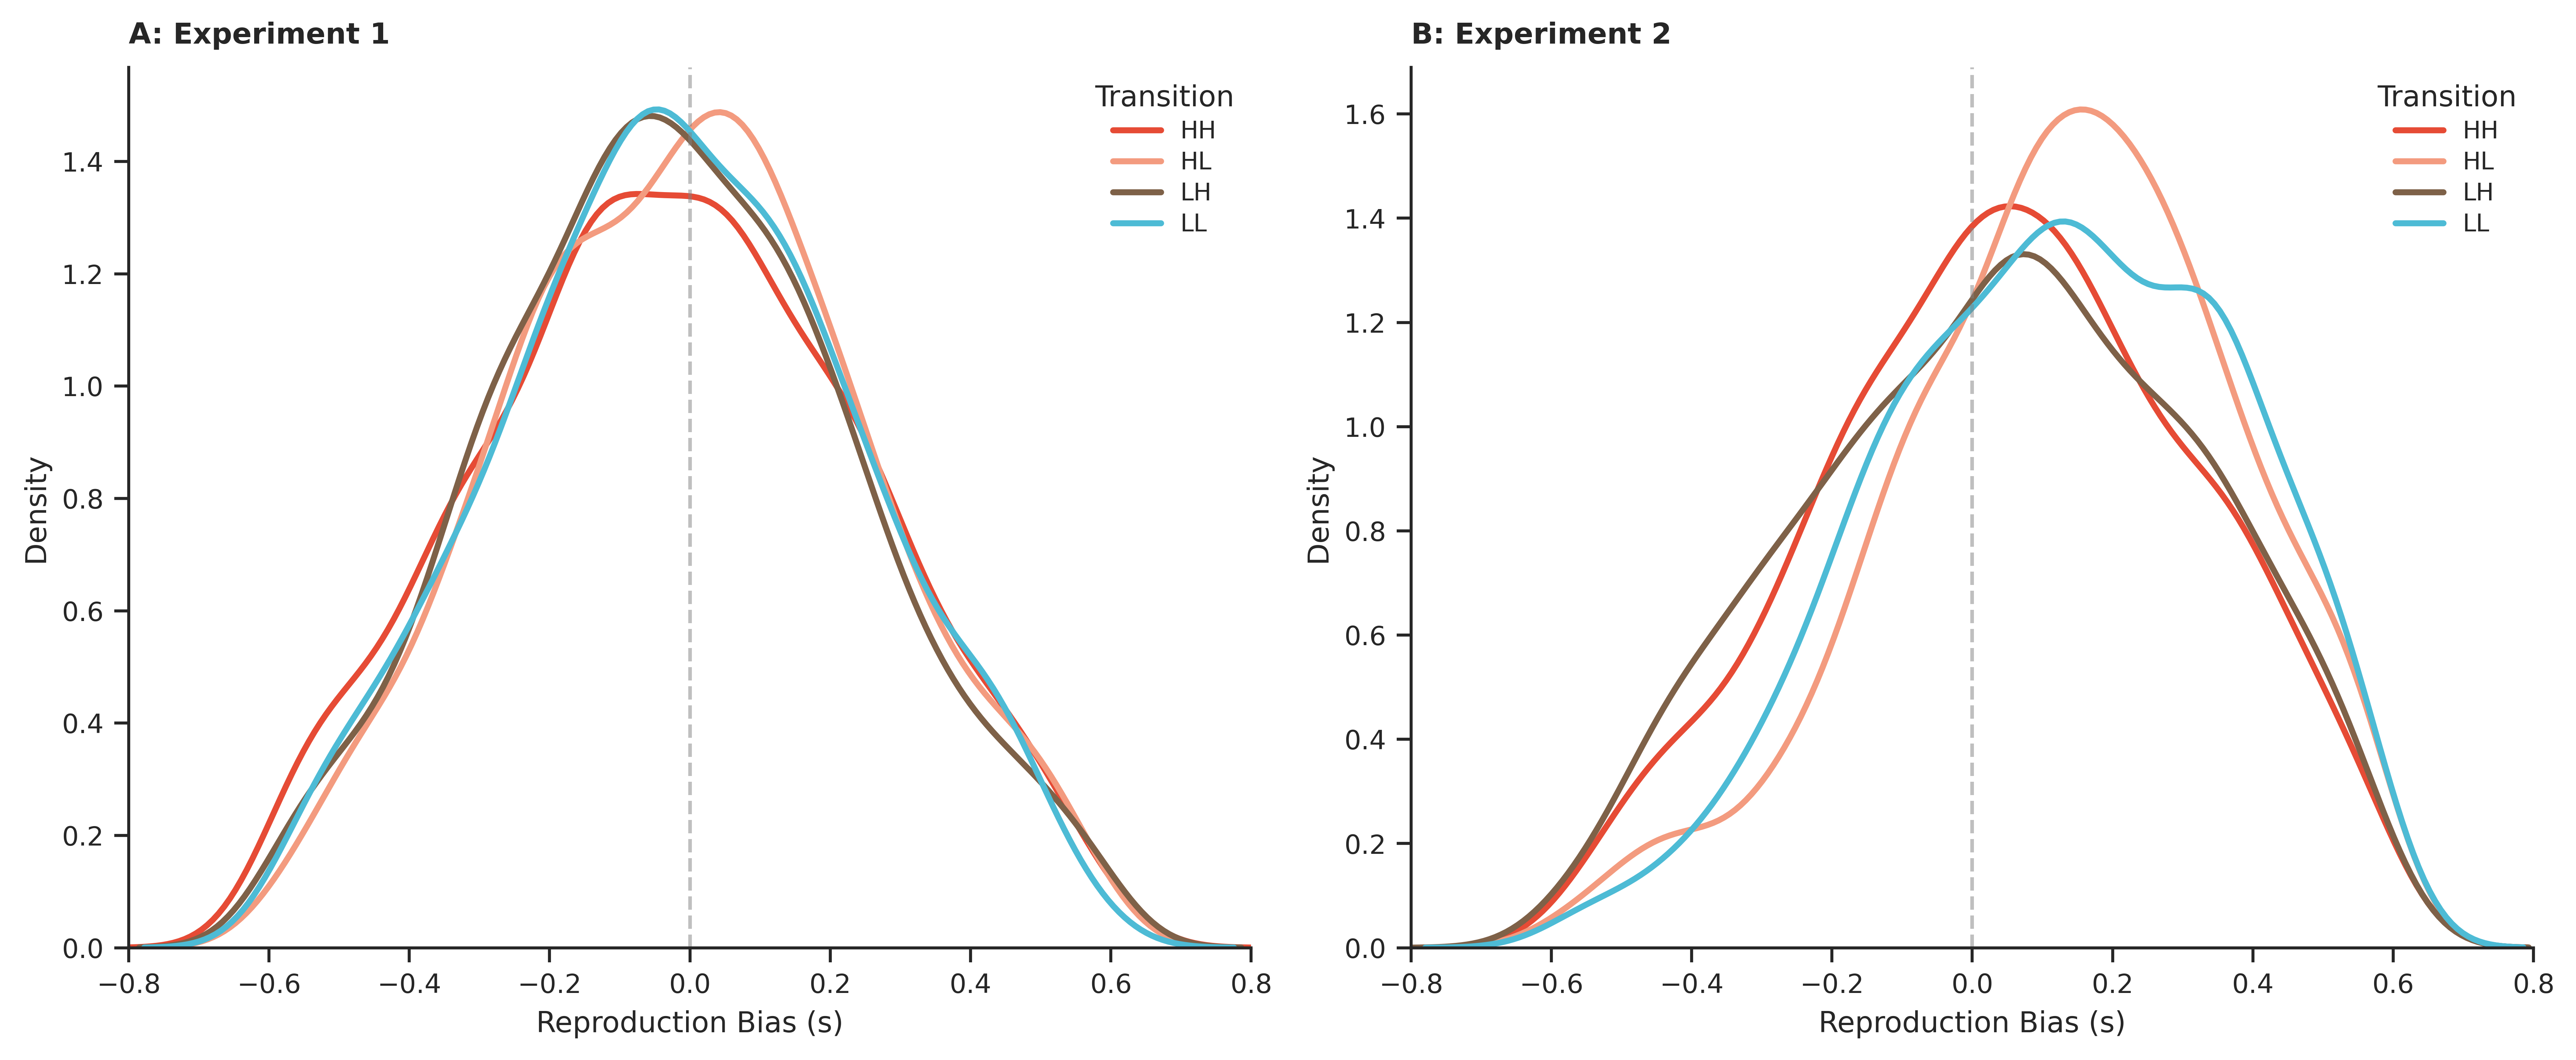

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for trans in TRANSITION_ORDER:
    trans_data = df1[df1['TransitionType'] == trans]['curBias']
    sns.kdeplot(trans_data, ax=ax, label=trans, color=COLORS[trans], lw=2)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Reproduction Bias (s)')
ax.set_ylabel('Density')
ax.set_title('A: Experiment 1', loc='left', fontweight='bold')
ax.legend(title='Transition', frameon=False, fontsize=8)
ax.set_xlim(-0.8, 0.8)
despine(ax)

ax = axes[1]
for trans in TRANSITION_ORDER:
    trans_data = df2[df2['TransitionType'] == trans]['curBias']
    sns.kdeplot(trans_data, ax=ax, label=trans, color=COLORS[trans], lw=2)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Reproduction Bias (s)')
ax.set_ylabel('Density')
ax.set_title('B: Experiment 2', loc='left', fontweight='bold')
ax.legend(title='Transition', frameon=False, fontsize=8)
ax.set_xlim(-0.8, 0.8)
despine(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / 'figS4_bias_dist.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Summary

In [22]:
import os

print("=" * 60)
print("FIGURE SUMMARY")
print("=" * 60)

print("\nBehavioral Figures (1-5):")
print("  1. Experimental Design (direct reference)")
print("  2. Central Tendency (Exp 1 & 2)")
print("  3. Serial Dependence (4 panels)")
print("  4. Sanity Check (n-3 to n+2)")
print("  5. Cross-Experiment (SDI comparison + Decision Carryover)")

print("\nComputational Modeling Figures (6-10):")
print("  6. Model Comparison (Axis Comparison)")
print("  7. Best Model Parameters:")
print("     7A: Experiment 1 - all fitted parameters")
print("     7B: Experiment 2 - all fitted parameters")
print("  8. CTI & SDI Recovery (PPC scatter plots)")
print("  9. SDI vs CTI (with prominent mean points)")
print("  10. Trial-Level SD Pattern")

print("\nSupplementary Figures (S1-S4):")
print("  S1. CTI Detail - Experiment 1")
print("  S2. CTI Detail - Experiment 2")
print("  S3. 10-back Serial Dependence")
print("  S4. Bias Distributions")

print("\n" + "=" * 60)
print("Generated PNG files:")
print("=" * 60)

fig_files = sorted([f for f in os.listdir(FIG_DIR) if f.startswith('fig') and f.endswith('.png')])
for f in fig_files:
    print(f"  {f}")

print(f"\nTotal: {len(fig_files)} PNG files")
print("Note: PDF versions also saved.")

FIGURE SUMMARY

Behavioral Figures (1-5):
  1. Experimental Design (direct reference)
  2. Central Tendency (Exp 1 & 2)
  3. Serial Dependence (4 panels)
  4. Sanity Check (n-3 to n+2)
  5. Cross-Experiment (SDI comparison + Decision Carryover)

Computational Modeling Figures (6-10):
  6. Model Comparison (Axis Comparison)
  7. Best Model Parameters:
     7A: Experiment 1 - all fitted parameters
     7B: Experiment 2 - all fitted parameters
  8. CTI & SDI Recovery (PPC scatter plots)
  9. SDI vs CTI (with prominent mean points)
  10. Trial-Level SD Pattern

Supplementary Figures (S1-S4):
  S1. CTI Detail - Experiment 1
  S2. CTI Detail - Experiment 2
  S3. 10-back Serial Dependence
  S4. Bias Distributions

Generated PNG files:
  fig10_sdi_vs_cti.png
  fig2_central_tendency.png
  fig3_serial_dependence.png
  fig4_sanity_check.png
  fig5_cross_experiment.png
  fig7_model_comparison.png
  fig7_parameters.png
  fig8_parameters.png
  fig8_trial_level_sd.png
  fig9_cti_sdi_recovery.png
  fi